# TP Final — Aprendizaje de Maquina I
## Prediccion del Precio de Venta de Autos Usados con Machine Learning

**Integrantes:** Cristhian Pettico — Rodolfo Di Chiazza  
**Curso:** Aprendizaje de Maquina I | CEIA — FIUBA  
**Fecha:** Junio 2026

---



### Indice
1. Propuesta de investigación (sección 1)
2. Fuente y descripción de los datos (secciones 2-4)
3. Preparación del dataset: deduplicación, split y creación de variables (secciones 5-7)
4. Análisis exploratorio de datos: target, variables, faltantes y outliers (secciones 8-10)
5. Preprocesamiento: codificación y escalado (sección 11)
6. Entrenamiento de modelos: baseline, lineales, KNN, SVR, árbol y ensambles (secciones 12-21)
7. Comparación final y elección del modelo (sección 22)
8. Análisis de errores del modelo elegido (sección 23)
9. Conclusiones y reflexión final (sección 24)

---

# 1. Propuesta de Investigación

### Motivacion y Pregunta Central

El mercado de **automóviles usados** es complejo de evaluar: el precio depende simultáneamente de la antigüedad, el kilometraje, la potencia del motor, el combustible, el historial de propietarios y factores de mercado. Conceptualmente podemos agrupar esos factores en cuatro bloques: **características y prestaciones**, **estado del auto**, **microcontexto de la venta** (vendedor, dueños) y **macrocontexto de la venta** (situación económica al momento de la operación). En general, el precio es una función de todos esos bloques:

$$Precio = F(\text{prestaciones},\ \text{estado},\ \text{microcontexto},\ \text{macrocontexto})$$

Sin embargo, no observamos todos los factores. De las prestaciones tenemos buena información; del estado solo observamos *proxies* de uso (antigüedad, kilometraje), no la condición real; el macrocontexto es constante en este corte temporal (todas las ventas son de 2020) y la negociación comprador–vendedor no se mide. Agrupando lo observable en un conjunto de variables $X$ y absorbiendo lo no observado en un término de error $\epsilon$, el problema que efectivamente modelamos es:

$$Precio = H(X_{\text{observable}}) + \epsilon$$

donde $\epsilon$ integra el estado real del vehículo, la negociación, el macrocontexto (constante) y el ruido inherente del mercado. Como el precio presenta fuerte asimetría positiva (ver EDA), modelamos su logaritmo:

$$\log(1 + Precio) = H(X_{\text{observable}}) + \epsilon$$

En este trabajo aplicamos técnicas de **Machine Learning supervisado** para estimar $H$ y predecir el precio a partir de las características observables. La pregunta central de investigación es:

> *¿Es posible predecir con precisión el precio de venta de un automóvil usado a partir de sus características técnicas e historial de uso?*

### Objetivos Especificos
1. Explorar y comprender la distribucion y correlaciones entre las variables del dataset.
2. Comparar el desempeño de un baseline heurístico frente a modelos de regresión de distintas familias: lineales (Regresión Lineal, Ridge), no paramétrico (KNN), de kernel (SVR), de árbol (Árbol de decisión) y de ensamble (Random Forest, XGBoost, LightGBM).
3. Seleccionar y justificar el modelo con mejor desempeño predictivo.
4. Interpretar que variables tienen mayor impacto en la determinacion del precio.
5. Proponer caminos de mejora y extension del trabajo.

---

# 2. Fuente de los Datos

Los datos provienen de **Kaggle**, publicados originalmente por el portal indio [**CardEkho**](https://www.cardekho.com/), una de las plataformas mas grandes de compraventa de automoviles de la India:

| Dataset | Filas | Columnas | Descripcion |
|---------|-------|----------|-------------|
| Car Data | 301 | 9 | Dataset base con precios en Lakhs (INR / 1e5) |
| CAR DETAILS FROM CAR DEKHO | 4.340 | 8 | Precios en INR, sin variables tecnicas |
| **Car details v3** | **8.128** | **13** | Incluye mileage, engine cc, max_power, seats — **dataset principal** |
| Car details v4 | 2.059 | 20 | Agrega dimensiones fisicas del vehiculo |

**Referencia:** Nehal Birla, *"Vehicle Dataset from CarDekho"*, Kaggle, 2020.  
URL: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

> **Justificacion de la fuente:** CardEkho es una plataforma de transacciones reales del mercado secundario de automoviles en India. Los datos reflejan operaciones efectivas de compraventa, lo que los hace representativos para modelar la dinamica de precios del mercado. Los precios estan expresados en **Rupias Indias (INR)**.

## Descripción de datasets: ventas de autos usados en India

Estos cuatro datasets contienen información sobre autos usados en India.  
Todos pueden utilizarse para tareas de análisis exploratorio, limpieza de datos y modelos de predicción de precios.

---

## 1. `CAR DETAILS FROM CAR DEKHO.csv`

| Columna | Descripción |
|---|---|
| `name` | Nombre del auto. |
| `year` | Año del auto o año en que fue comprado. |
| `selling_price` | Precio al que el auto está siendo vendido. |
| `km_driven` | Cantidad de kilómetros recorridos por el auto. |
| `fuel` | Tipo de combustible: petrol, diesel, CNG, LPG o electric. |
| `seller_type` | Tipo de vendedor: individual o dealer. |
| `transmission` | Tipo de transmisión: manual o automática. |
| `owner` | Cantidad de dueños anteriores del auto. |

---

## 2. `car data.csv`

| Columna | Descripción |
|---|---|
| `Car_Name` | Nombre del auto. |
| `Year` | Año en que el auto fue comprado. |
| `Selling_Price` | Precio al que el dueño quiere vender el auto. |
| `Present_Price` | Precio actual del auto en showroom. |
| `Kms_Driven` | Distancia recorrida por el auto, medida en kilómetros. |
| `Fuel_Type` | Tipo de combustible del auto. |
| `Seller_Type` | Indica si el vendedor es dealer o individual. |
| `Transmission` | Indica si el auto es manual o automático. |
| `Owner` | Número de dueños anteriores del auto. |

---

## 3. `car details v4.csv`

| Columna | Descripción |
|---|---|
| `Make` | Marca o empresa fabricante del auto. |
| `Model` | Modelo del auto. |
| `Price` | Precio de venta del auto en rupias indias, INR. |
| `Year` | Año de fabricación del auto. |
| `Kilometer` | Total de kilómetros recorridos por el auto. |
| `Fuel Type` | Tipo de combustible del auto. |
| `Transmission` | Tipo de transmisión del auto. |
| `Location` | Ciudad en la que el auto está siendo vendido. |
| `Color` | Color del auto. |
| `Owner` | Número de dueños anteriores. |
| `Seller Type` | Tipo de vendedor: individual, corporate, dealer, etc. |
| `Engine` | Capacidad del motor en centímetros cúbicos, cc. |
| `Max Power` | Potencia máxima del motor, expresada en bhp@rpm. |
| `Max Torque` | Torque máximo del motor, expresado en Nm@rpm. |
| `Drivetrain` | Tipo de tracción: AWD, RWD o FWD. |
| `Length` | Largo del auto en milímetros. |
| `Width` | Ancho del auto en milímetros. |
| `Height` | Altura del auto en milímetros. |
| `Seating Capacity` | Capacidad máxima de pasajeros. |
| `Fuel Tank Capacity` | Capacidad máxima del tanque de combustible, en litros. |

---

## 4. `Car details v3.csv`

| Columna | Descripción |
|---|---|
| `name` | Nombre del auto. |
| `year` | Año en que el auto fue comprado. |
| `selling_price` | Precio de venta del auto. |
| `km_driven` | Número de kilómetros recorridos por el auto. |
| `fuel` | Tipo de combustible del auto. |
| `seller_type` | Indica si el auto es vendido por un individuo o un dealer. |
| `transmission` | Tipo de transmisión: manual o automática. |
| `owner` | Número de dueños anteriores. |
| `mileage` | Rendimiento o kilometraje del auto, usualmente expresado en km/l o km/kg. |
| `engine` | Capacidad del motor del auto. |
| `max_power` | Potencia máxima del motor. |
| `torque` | Torque del auto. |
| `seats` | Número de asientos del auto. |

---



## Comparación general entre datasets

| Dataset | Cantidad de columnas | Característica principal |
|---|---:|---|
| `CAR DETAILS FROM CAR DEKHO.csv` | 8 | Dataset simple con variables básicas del auto y del vendedor. |
| `car data.csv` | 9 | Incluye `Present_Price`, útil para comparar precio actual vs. precio de venta. |
| `Car details v3.csv` | 13 | Versión intermedia; agrega variables técnicas como mileage, engine, max_power, torque y seats. |
| `car details v4.csv` | 20 | Dataset más completo; incluye marca, modelo, ciudad, color, motor, potencia, torque, dimensiones y capacidad. |


---

## Tabla comparativa de columnas de los datasets

Los cuatro datasets describen autos usados, pero usan **nombres distintos para las mismas variables**. La siguiente tabla agrupa las columnas por concepto y muestra el nombre real en cada archivo.

| Concepto | CAR_DEKHO | Car_details_v3 | car_data | car_details_v4 |
|---|---|---|---|---|
| **Nombre / modelo** | `name` | `name` | `Car_Name` | `Make` + `Model` |
| **Año** | `year` | `year` | `Year` | `Year` |
| **Precio de venta** | `selling_price` | `selling_price` | `Selling_Price` | `Price` |
| **Kilómetros** | `km_driven` | `km_driven` | `Kms_Driven` | `Kilometer` |
| **Combustible** | `fuel` | `fuel` | `Fuel_Type` | `Fuel Type` |
| **Tipo de vendedor** | `seller_type` | `seller_type` | `Seller_Type` | `Seller Type` |
| **Transmisión** | `transmission` | `transmission` | `Transmission` | `Transmission` |
| **Dueño (nº propietarios)** | `owner` | `owner` | `Owner` | `Owner` |
| Precio nuevo / actual | — | — | `Present_Price` | — |
| Rendimiento (mileage) | — | `mileage` | — | — |
| Motor (cilindrada) | — | `engine` | — | `Engine` |
| Potencia máxima | — | `max_power` | — | `Max Power` |
| Torque | — | `torque` | — | `Max Torque` |
| Asientos | — | `seats` | — | `Seating Capacity` |
| Ubicación | — | — | — | `Location` |
| Color | — | — | — | `Color` |
| Tracción | — | — | — | `Drivetrain` |
| Dimensiones (largo/ancho/alto) | — | — | — | `Length`, `Width`, `Height` |
| Capacidad del tanque | — | — | — | `Fuel Tank Capacity` |

**Núcleo común a los 4 datasets (8 columnas):** nombre, año, precio de venta, kilómetros, combustible, tipo de vendedor, transmisión y dueño. El resto son columnas adicionales propias de cada archivo.

---

# Librerias

In [2]:
# Librerías base
import re
import time
import numpy as np
import pandas as pd

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.graph_objects as go

import missingno as msno

# Estadística
from scipy import stats

# Scikit-learn: partición, validación y métricas
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Scikit-learn: preprocesamiento e imputación
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Modelos
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Optimización de hiperparámetros
import optuna


---

# 3. Estructura básica de los datasets

In [3]:
# Carga de datos
def load_datasets():
    datasets = {
        'car_data': pd.read_csv('dataset/car data.csv'),
        'car_details': pd.read_csv('dataset/CAR DETAILS FROM CAR DEKHO.csv'),
        'car_details_v3': pd.read_csv('dataset/Car details v3.csv'),
        'car_details_v4': pd.read_csv('dataset/car details v4.csv')
    }
    return datasets

In [4]:
datasets = load_datasets()
print("Datasets cargados:")
for name, df in datasets.items():
    print(f"{name}: {df.shape} registros")

Datasets cargados:
car_data: (301, 9) registros
car_details: (4340, 8) registros
car_details_v3: (8128, 13) registros
car_details_v4: (2059, 20) registros


In [5]:
for name in ['car_data', 'car_details', 'car_details_v3', 'car_details_v4']:
    print(f"\n=== {name} ===")
    display(datasets[name].head(5))


=== car_data ===


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



=== car_details ===


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



=== car_details_v3 ===


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0



=== car_details_v4 ===


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [6]:
for name in ['car_data', 'car_details', 'car_details_v3', 'car_details_v4']:
    print(f"\n=== {name} ===")
    display(datasets[name].info())


=== car_data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None


=== car_details ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


None


=== car_details_v3 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


None


=== car_details_v4 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-nu

None

In [7]:
def show_samples(datasets):
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_rows', 20)

    print("\nMuestra de 3 registros aleatorios de cada dataset:")
    for name, df in datasets.items():
        print(f"\n{'='*100}")
        print(f"{name.upper()}")
        print(f"{'='*100}")
        print(df.sample(3, random_state=42).to_string())
        print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
        print(f"Columnas: {', '.join(df.columns)}")

show_samples(datasets)


Muestra de 3 registros aleatorios de cada dataset:

CAR_DATA
             Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
177  Honda Activa 125  2016           0.35           0.57       24000    Petrol  Individual    Automatic      0
289              city  2016          10.11          13.60       10980    Petrol      Dealer       Manual      0
228             verna  2012           4.95           9.40       60000    Diesel      Dealer       Manual      0

Dimensiones del dataset: 301 filas x 9 columnas
Columnas: Car_Name, Year, Selling_Price, Present_Price, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner

CAR_DETAILS
                                 name  year  selling_price  km_driven    fuel seller_type transmission         owner
3978  Tata Manza Aqua Quadrajet BS IV  2010         165000      80000  Diesel  Individual       Manual   First Owner
1448            Renault KWID RXT BSIV  2019         250000      27000  Petrol  Ind

In [8]:
# Algunas características básicas de los datasets:

def initial_analysis(df):
    analysis = {
        'shape': df.shape,
        'dtypes': df.dtypes,
        'null_values': (df.isnull().sum()/len(df) * 100).round(2),
        'duplicates': df.duplicated().sum(),
        'description': df.describe()
    }
    return analysis

In [9]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Análisis del dataset: {name}")
    print(f"{'='*50}")

    results = initial_analysis(df)

    print("\nDimensiones del dataset:")
    print(results['shape'])

    print("\nValores nulos por columna:")
    print(results['null_values'])

    print("\nNúmero de registros duplicados:")
    print(results['duplicates'])

    print("\nEstadísticas descriptivas:")
    print(results['description'])


Análisis del dataset: car_data

Dimensiones del dataset:
(301, 9)

Valores nulos por columna:
Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64

Número de registros duplicados:
2

Estadísticas descriptivas:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000

---

# 4. Selección del dataset para trabajar

Se selecciona **`car_details_v3`** como dataset principal por contener variables tecnicas relevantes (`mileage`, `engine`, `max_power`, `seats`), un % bajo de nulos y ser el de mayor cantidad de registros (8.128 filas). Los otros datasets podrían usarse para complementar la comprension.

In [10]:
# Dataset principal para el modelo
df_raw = datasets['car_details_v3'].copy()


---

# 5. Eliminación de filas duplicadas

In [11]:
n_antes = len(df_raw)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Registros eliminados: {n_antes - len(df_raw):,}  ({n_antes} → {len(df_raw)})")

Registros eliminados: 1,202  (8128 → 6926)


---

# 6. Split Train / Test

Se divide de tal manera de conservar una distribución parecida de precios bajos, intermedios y altos entre Train y Test.

Para lograr esto, se ordenan los precios de mayor a menor y se dividen todas las filas en 5 bloques. De cada bloque, se toma el 75% para Train y el 25% para Test.

In [12]:
# ── Bins de precio
# qcut divide en 5 quintiles: grupos parejos en cantidad de autos
price_bins = pd.qcut(
    df_raw['selling_price'],
    q=5,
    labels=['muy_barato', 'barato', 'intermedio', 'caro', 'muy_caro']
)

In [13]:
# ── Split train/test (75/25) estratificado por esos bins ──
df_train, df_test = train_test_split(
    df_raw,
    test_size=0.25,
    stratify=price_bins,
    random_state=42
)

In [14]:
# ── Verificación ──
print(f"Total : {len(df_raw):,} autos")
print(f"Train : {len(df_train):,} autos  ({len(df_train)/len(df_raw)*100:.0f}%)")
print(f"Test  : {len(df_test):,} autos  ({len(df_test)/len(df_raw)*100:.0f}%)")

print("\nProporción de cada bin de precio (deben ser casi idénticas):")
comp = pd.DataFrame({
    'Train (%)': pd.qcut(df_train['selling_price'], q=5,
                         labels=['muy_barato','barato','intermedio','caro','muy_caro']
                        ).value_counts(normalize=True).sort_index() * 100,
    'Test (%)':  pd.qcut(df_test['selling_price'], q=5,
                         labels=['muy_barato','barato','intermedio','caro','muy_caro']
                        ).value_counts(normalize=True).sort_index() * 100,
})
print(comp.round(1).to_string())

Total : 6,926 autos
Train : 5,194 autos  (75%)
Test  : 1,732 autos  (25%)

Proporción de cada bin de precio (deben ser casi idénticas):
               Train (%)  Test (%)
selling_price                     
muy_barato          20.2      20.3
barato              19.9      19.9
intermedio          21.8      21.8
caro                19.6      19.6
muy_caro            18.4      18.4


# 7. Creación de columnas

In [15]:
# ── Extracción de marca, modelo, variante y separación de número + unidad ──

MARCAS_DOS_PALABRAS = {'Land Rover', 'Ashok Leyland'}

def extraer_marca_modelo(name):
    if pd.isna(name):
        return pd.Series([np.nan, np.nan, np.nan])
    tokens = name.strip().split()
    dos = ' '.join(tokens[:2])
    if dos in MARCAS_DOS_PALABRAS:
        marca, modelo, resto = dos, (tokens[2] if len(tokens) > 2 else np.nan), ' '.join(tokens[3:])
    else:
        marca, modelo, resto = tokens[0], (tokens[1] if len(tokens) > 1 else np.nan), ' '.join(tokens[2:])
    return pd.Series([marca, modelo, resto if resto else np.nan])

def split_num_unidad(serie):
    num    = pd.to_numeric(serie.astype(str).str.extract(r'(-?[\d.]+)')[0], errors='coerce')
    unidad = serie.astype(str).str.extract(r'[\d.]+\s*([A-Za-z/]+)')[0].str.strip()
    return num, unidad

def parse_torque(t):
    if pd.isna(t):
        return pd.Series([np.nan, np.nan, np.nan])
    s = str(t)
    m_val = re.search(r'([\d.]+)', s)
    val   = float(m_val.group(1)) if m_val else np.nan
    unit  = 'kgm' if 'kgm' in s.lower() else ('Nm' if 'nm' in s.lower() else np.nan)
    rpm   = re.search(r'([\d,\-\s]+)\s*rpm', s, re.IGNORECASE)
    rpm_txt = rpm.group(1).replace(',', '').strip() if rpm else np.nan
    return pd.Series([val, unit, rpm_txt])

def extraer_columnas_tecnicas(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[['brand', 'model', 'variant']] = df['name'].apply(extraer_marca_modelo)
    df['mileage_value'],   df['mileage_unit']   = split_num_unidad(df['mileage'])
    df['engine_value'],    df['engine_unit']    = split_num_unidad(df['engine'])
    df['max_power_value'], df['max_power_unit']  = split_num_unidad(df['max_power'])
    df[['torque_value', 'torque_unit', 'torque_rpm']] = df['torque'].apply(parse_torque)
    df['torque_nm'] = np.where(df['torque_unit'] == 'kgm',
                               df['torque_value'] * 9.80665,
                               df['torque_value'])
    df['car_age'] = 2020 - df['year']
    return df

# Aplicar por separado a train y test (evita data leakage)
df_train = extraer_columnas_tecnicas(df_train)
df_test  = extraer_columnas_tecnicas(df_test)

# Verificación
df_train[['name', 'brand', 'model', 'variant','car_age',
          'mileage_value', 'mileage_unit', 'engine_value', 'engine_unit',
          'max_power_value', 'max_power_unit',
          'torque_value', 'torque_unit', 'torque_rpm', 'torque_nm']].head()

,name,brand,model,variant,car_age,mileage_value,mileage_unit,engine_value,engine_unit,max_power_value,max_power_unit,torque_value,torque_unit,torque_rpm,torque_nm
5113,Mahindra Scorpio SLE BSIV,Mahindra,Scorpio,SLE BSIV,10,12.05,kmpl,2179.0,CC,120.0,bhp,290.0,Nm,1800-2800,290.000000
4656,Hyundai Verna Transform VGT CRDi,Hyundai,Verna,Transform VGT CRDi,10,16.20,kmpl,1493.0,CC,110.0,bhp,24.0,kgm,1900-2750,235.359600
4,Maruti Swift VXI BSIII,Maruti,Swift,VXI BSIII,13,16.10,kmpl,1298.0,CC,88.2,bhp,11.5,kgm,,112.776475
3413,Mahindra Bolero 2011-2019 Special Edition,Mahindra,Bolero,2011-2019 Special Edition,5,15.96,kmpl,2523.0,CC,62.1,bhp,195.0,Nm,1400-2200,195.000000
1801,Ford Figo 1.5D Titanium MT,Ford,Figo,1.5D Titanium MT,5,25.83,kmpl,1498.0,CC,99.0,bhp,215.0,Nm,1750-3000,215.000000


### Relaciones físicas entre las variables técnicas

Las variables técnicas extraídas no son independientes entre sí: están ligadas por la física del motor. Conviene tenerlo presente porque implica **multicolinealidad** (variables que aportan información redundante), lo cual afecta sobre todo a los modelos lineales.

#### 1. Relación exacta: potencia, torque y rpm

La potencia es el producto del torque por la velocidad de giro. La relación es una igualdad física:

$$\text{Potencia (kW)} = \frac{\text{Torque (Nm)} \times \text{rpm} \times 2\pi}{60{,}000}$$

O de forma equivalente en las unidades del dataset (bhp y Nm):

$$\text{Potencia (bhp)} \approx \frac{\text{Torque (Nm)} \times \text{rpm}}{7127}$$

**Implicación:** `max_power_bhp`, `torque_nm` y `torque_rpm` están matemáticamente vinculadas. No son tres piezas de información completamente nuevas; conocidas dos, la tercera queda fuertemente restringida. Esto explica por qué `engine`, `max_power` y `torque` suelen estar muy correlacionadas entre sí.

#### 2. Conversión de unidades dentro de torque

El torque venía en dos unidades distintas en el dataset original:

$$1 \text{ kgm} = 9{,}80665 \text{ Nm}$$

Por eso se creó `torque_nm`, que unifica todos los valores a Newton-metros y los hace comparables entre autos.

#### 3. Relaciones de correlación (no exactas pero fuertes)

| Relación | Naturaleza | Comentario |
|---|---|---|
| `engine_cc` ↔ `max_power_bhp` | Correlación física | Motores de mayor cilindrada tienden a entregar más potencia, pero la eficiencia varía según tecnología (turbo, inyección). |
| `engine_cc` ↔ `torque_nm` | Correlación física | Más cilindrada suele implicar más torque, aunque no de forma lineal exacta. |
| `engine_cc` ↔ `mileage_value` | Correlación inversa | Motores más grandes tienden a rendir menos km por litro. |
| `max_power_bhp` ↔ `torque_nm` | Correlación fuerte | Ligadas por la fórmula de potencia anterior. |

#### Consecuencia para el modelado

- En **modelos lineales** (Regresión Lineal, Ridge) esta multicolinealidad infla la varianza de los coeficientes y dificulta su interpretación. Ridge la mitiga parcialmente vía regularización.
- En **modelos basados en árboles** (Random Forest, XGBoost, LightGBM) la multicolinealidad no es un problema para la *predicción*, pero sí reparte la importancia entre variables redundantes, lo que puede dificultar leer qué feature "manda".
- **`mileage`** mide algo distinto (eficiencia de consumo) y no está ligada por una fórmula exacta a las demás, aunque sí correlaciona con la cilindrada.

In [16]:
dtypes = df_train.dtypes.astype(str)

originales = dtypes.loc[:'seats']
creadas = dtypes.loc['brand':]

print("Variables originales:\n")
print(originales.to_string())

print("\n" + "-"*40 + "\n")

print("Variables creadas:\n")
print(creadas.to_string())

Variables originales:

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64

----------------------------------------

Variables creadas:

brand               object
model               object
variant             object
mileage_value      float64
mileage_unit        object
engine_value       float64
engine_unit         object
max_power_value    float64
max_power_unit      object
torque_value       float64
torque_unit         object
torque_rpm          object
torque_nm          float64
car_age              int64


---

# 8. Análisis Exploratorio de Datos (EDA)

A continuación se exploran la distribucion del precio y la relación de las distintas variables con el precio. Las variables se van a dividir entre variables relaciones con características internas, externas, relacionas con el uso, con el microcontexto de la venta y con el macrocontexto de la venta.

### Precio (target)

El precio presenta una distribución más normal con la transformación logarítmica.
Esto es bueno para el análisis, por lo tanto, se usará el logaritmo del precio como variable target en el modelo.


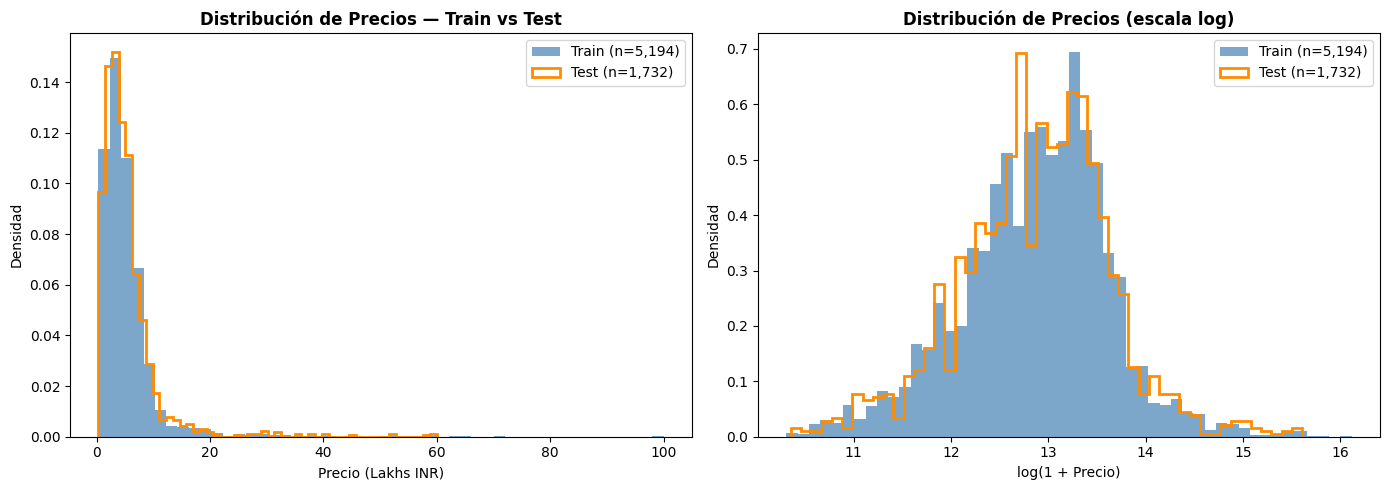

In [17]:
# Grafico de la variable target (precio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: histogramas superpuestos (en Lakhs para que se lea mejor) ──
axes[0].hist(df_train['selling_price'] / 1e5, bins=50, alpha=0.7,
             label=f'Train (n={len(df_train):,})', color='steelblue', density=True)
axes[0].hist(df_test['selling_price'] / 1e5, bins=50,
             label=f'Test (n={len(df_test):,})', color='darkorange', density=True,
             histtype='step', linewidth=2)
axes[0].set_title('Distribución de Precios — Train vs Test', fontweight='bold')
axes[0].set_xlabel('Precio (Lakhs INR)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# ── Derecha: lo mismo pero en escala log (se ve mejor la cola de autos caros) ──
axes[1].hist(np.log1p(df_train['selling_price']), bins=50, alpha=0.7,
             label=f'Train (n={len(df_train):,})', color='steelblue', density=True)
axes[1].hist(np.log1p(df_test['selling_price']), bins=50,
             label=f'Test (n={len(df_test):,})', color='darkorange', density=True,
             histtype='step', linewidth=2)
axes[1].set_title('Distribución de Precios (escala log)', fontweight='bold')
axes[1].set_xlabel('log(1 + Precio)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

print("El precio presenta una distribución más normal con la transformación logarítmica."
"\nEsto es bueno para el análisis, por lo tanto, se usará el logaritmo del precio como variable target en el modelo.")

plt.tight_layout()
plt.show()


---
### Relación de cada variable con el precio

Se exploran las variables agrupadas según su naturaleza. Todas las relaciones se grafican contra **log(1 + precio)** sobre el set de **train**, ya que es la escala en la que se modelará y donde las relaciones resultan más claras.

### 1. Características internas
Variables que describen el motor y las prestaciones mecánicas del vehículo: `brand`, `fuel`, `transmission`, `mileage`, `engine`, `max_power`, `torque`.

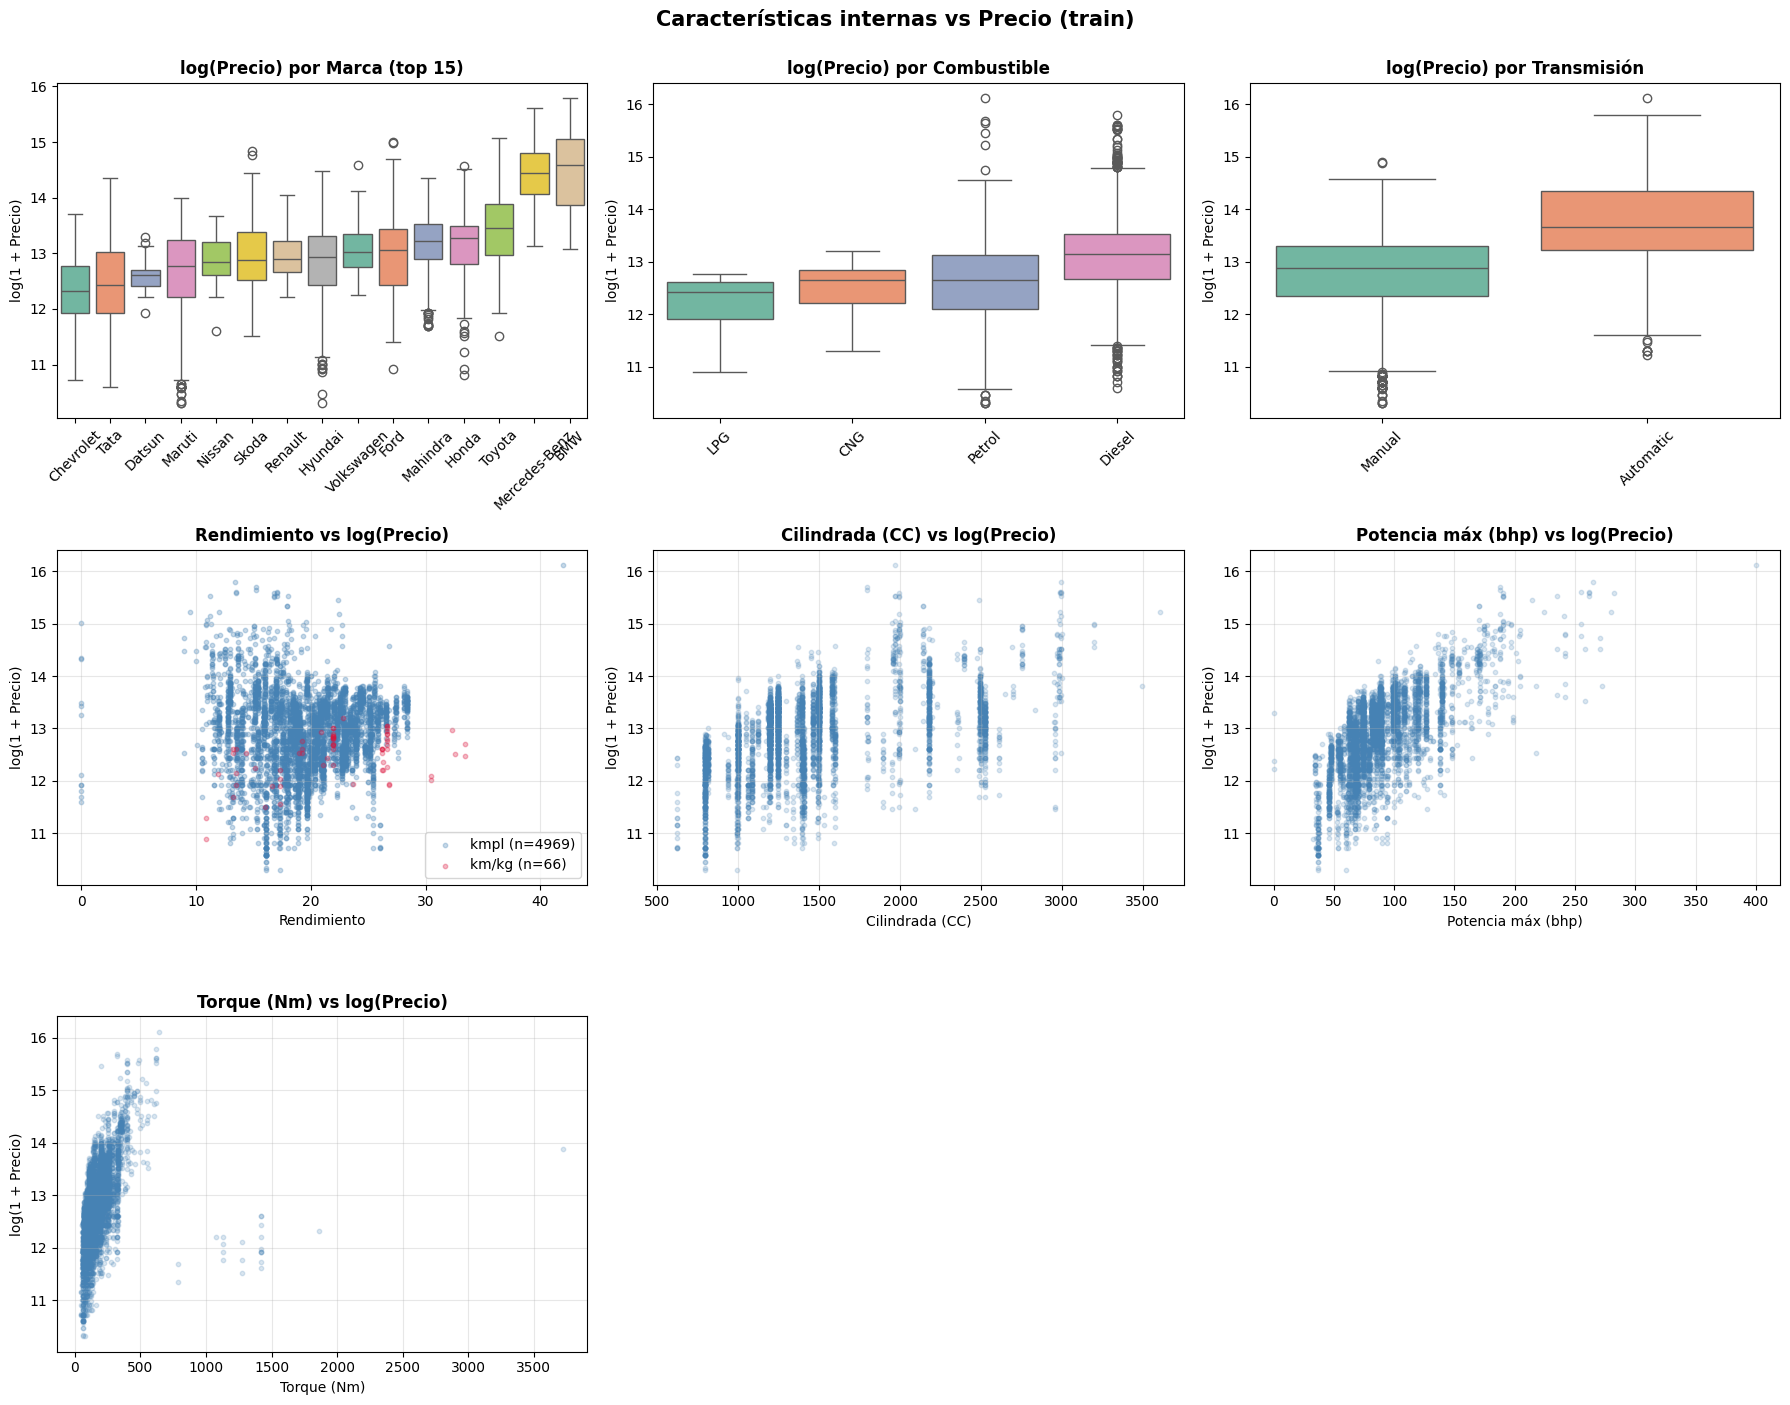

In [18]:
# ── 1. CARACTERÍSTICAS INTERNAS ──
log_price = np.log1p(df_train['selling_price'])

# Top 15 marcas (por frecuencia)
top15_brands = df_train['brand'].value_counts().head(15).index
df_top_brands = df_train[df_train['brand'].isin(top15_brands)].assign(log_price=log_price[df_train['brand'].isin(top15_brands)])

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flat

# --- Categóricas: boxplot ordenado por mediana ---
cat_internas = [
    ('brand', 'Marca (top 15)', df_top_brands),
    ('fuel', 'Combustible', df_train.assign(log_price=log_price)),
    ('transmission', 'Transmisión', df_train.assign(log_price=log_price)),
]
for ax, (col, titulo, data) in zip(axes, cat_internas):
    orden = data.groupby(col)['selling_price'].median().sort_values().index
    sns.boxplot(data=data, x=col, y='log_price',
                order=orden, hue=col, hue_order=orden,
                ax=ax, palette='Set2', legend=False)
    ax.set_title(f'log(Precio) por {titulo}', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('log(1 + Precio)')
    ax.tick_params(axis='x', rotation=45)

# --- Mileage: scatter coloreado por unidad ---
ax = axes[3]
colores = {'kmpl': 'steelblue', 'km/kg': 'crimson'}
for unidad, color in colores.items():
    mask = df_train['mileage_unit'] == unidad
    ax.scatter(df_train.loc[mask, 'mileage_value'], log_price[mask],
               alpha=0.3, s=10, color=color,
               label=f'{unidad} (n={mask.sum()})')
ax.set_title('Rendimiento vs log(Precio)', fontweight='bold')
ax.set_xlabel('Rendimiento'); ax.set_ylabel('log(1 + Precio)')
ax.legend()
ax.grid(alpha=0.3)

# --- Resto de numéricas: scatter ---
num_internas = [('engine_value',    'Cilindrada (CC)'),
                ('max_power_value', 'Potencia máx (bhp)'),
                ('torque_nm',       'Torque (Nm)')]
for ax, (col, titulo) in zip(axes[4:], num_internas):
    ax.scatter(df_train[col], log_price, alpha=0.2, s=10, color='steelblue')
    ax.set_title(f'{titulo} vs log(Precio)', fontweight='bold')
    ax.set_xlabel(titulo); ax.set_ylabel('log(1 + Precio)')
    ax.grid(alpha=0.3)

# Apagar ejes sobrantes
for ax in axes[7:]:
    ax.axis('off')

plt.suptitle('Características internas vs Precio (train)', y=1.0, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Características externas
Variables relacionadas con la configuración física/uso del habitáculo: `seats`.

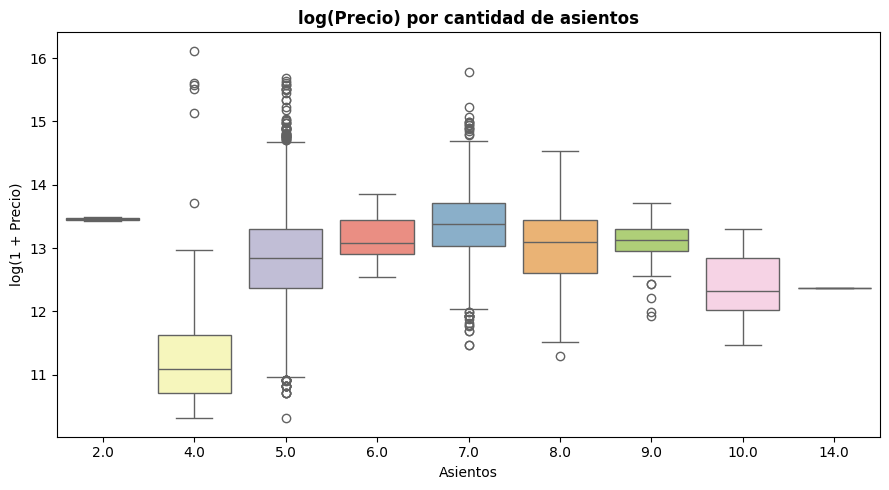

In [19]:
# ── 2. CARACTERÍSTICAS EXTERNAS ──
log_price = np.log1p(df_train['selling_price'])

fig, ax = plt.subplots(figsize=(9, 5))
orden = sorted(df_train['seats'].dropna().unique())
sns.boxplot(data=df_train.assign(log_price=log_price),
            x='seats', y='log_price', order=orden, hue='seats', hue_order=orden,
            ax=ax, palette='Set3', legend=False)
ax.set_title('log(Precio) por cantidad de asientos', fontweight='bold')
ax.set_xlabel('Asientos'); ax.set_ylabel('log(1 + Precio)')
plt.tight_layout()
plt.show()

### 3. Uso
Variables que reflejan el desgaste acumulado del vehículo: `car_age`, `km_driven`.

`car_age = 2020 - year` se construye asumiendo que el dataset, publicado en 2020, contiene listados de venta de ese período (no precios históricos).

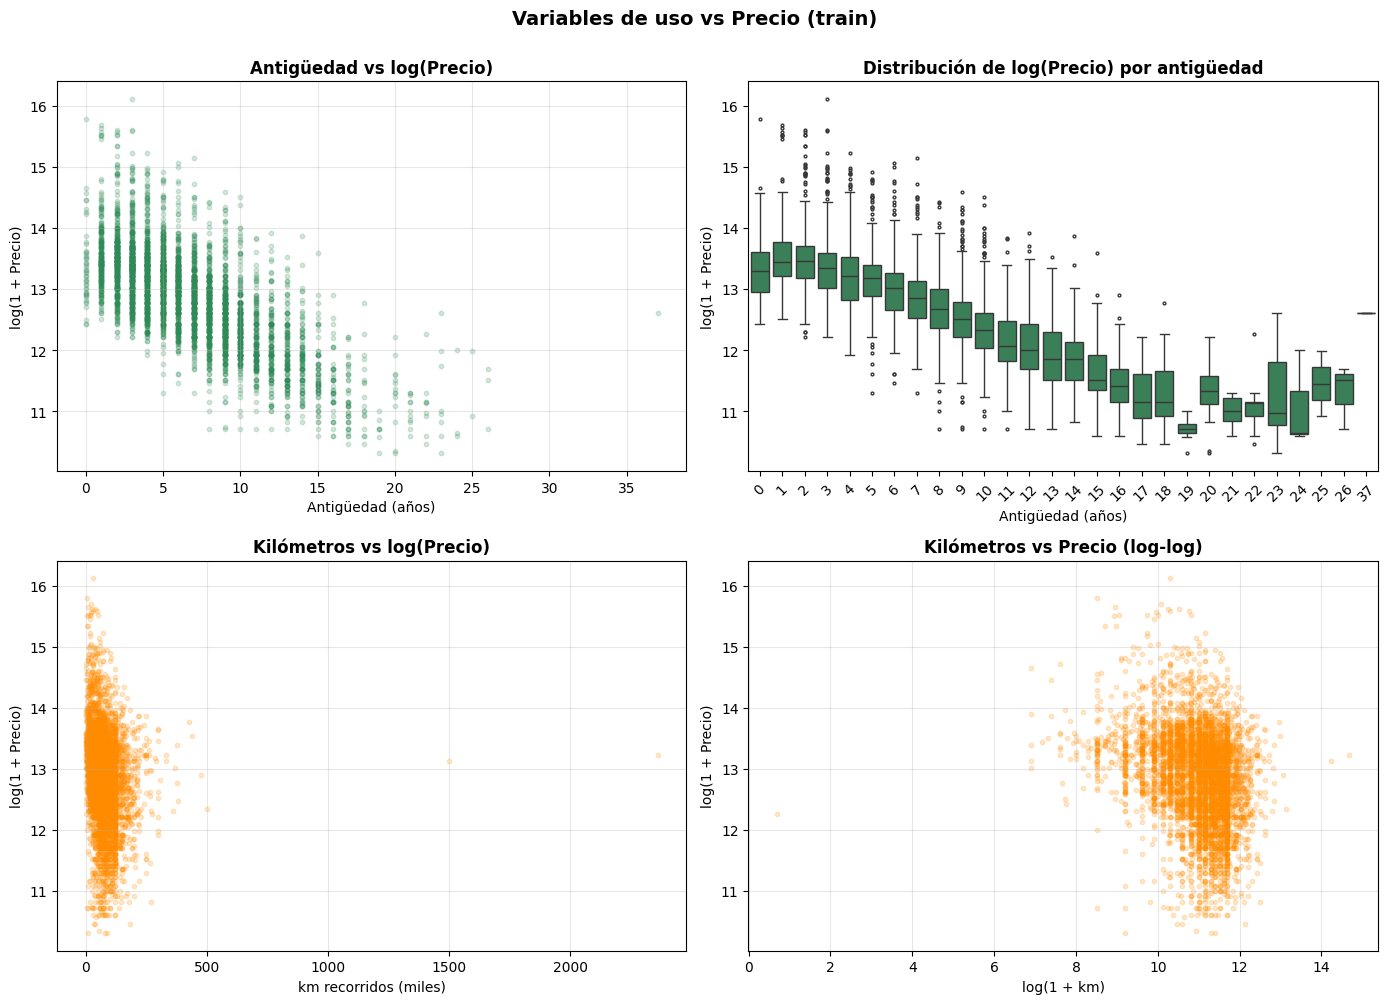


Correlación car_age ↔ km_driven: 0.360
(Esperable que sea positiva pero no perfecta: autos viejos suelen tener más km,
 pero un auto de uso intensivo puede acumular muchos km en pocos años, y viceversa.)


In [20]:
# ── 3. USO ──
log_price = np.log1p(df_train['selling_price'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- car_age: escala normal y boxplot ---
axes[0, 0].scatter(df_train['car_age'], log_price, alpha=0.2, s=10, color='seagreen')
axes[0, 0].set_title('Antigüedad vs log(Precio)', fontweight='bold')
axes[0, 0].set_xlabel('Antigüedad (años)'); axes[0, 0].set_ylabel('log(1 + Precio)')
axes[0, 0].grid(alpha=0.3)

# Boxplot por año (más legible para ver mediana y dispersión)
sns.boxplot(data=df_train.assign(log_price=log_price),
            x='car_age', y='log_price', ax=axes[0, 1],
            color='seagreen', fliersize=2)
axes[0, 1].set_title('Distribución de log(Precio) por antigüedad', fontweight='bold')
axes[0, 1].set_xlabel('Antigüedad (años)'); axes[0, 1].set_ylabel('log(1 + Precio)')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- km_driven: escala normal y log-log ---
axes[1, 0].scatter(df_train['km_driven'] / 1e3, log_price, alpha=0.2, s=10, color='darkorange')
axes[1, 0].set_title('Kilómetros vs log(Precio)', fontweight='bold')
axes[1, 0].set_xlabel('km recorridos (miles)'); axes[1, 0].set_ylabel('log(1 + Precio)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(np.log1p(df_train['km_driven']), log_price, alpha=0.2, s=10, color='darkorange')
axes[1, 1].set_title('Kilómetros vs Precio (log-log)', fontweight='bold')
axes[1, 1].set_xlabel('log(1 + km)'); axes[1, 1].set_ylabel('log(1 + Precio)')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Variables de uso vs Precio (train)', y=1.0, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación entre las dos variables de uso
corr_uso = df_train[['car_age', 'km_driven']].corr().iloc[0, 1]
print(f"\nCorrelación car_age ↔ km_driven: {corr_uso:.3f}")
print("(Esperable que sea positiva pero no perfecta: autos viejos suelen tener más km,")
print(" pero un auto de uso intensivo puede acumular muchos km en pocos años, y viceversa.)")

### 4. Microcontexto de la venta
Variables del contexto comercial de la operación: `owner`, `seller_type`.


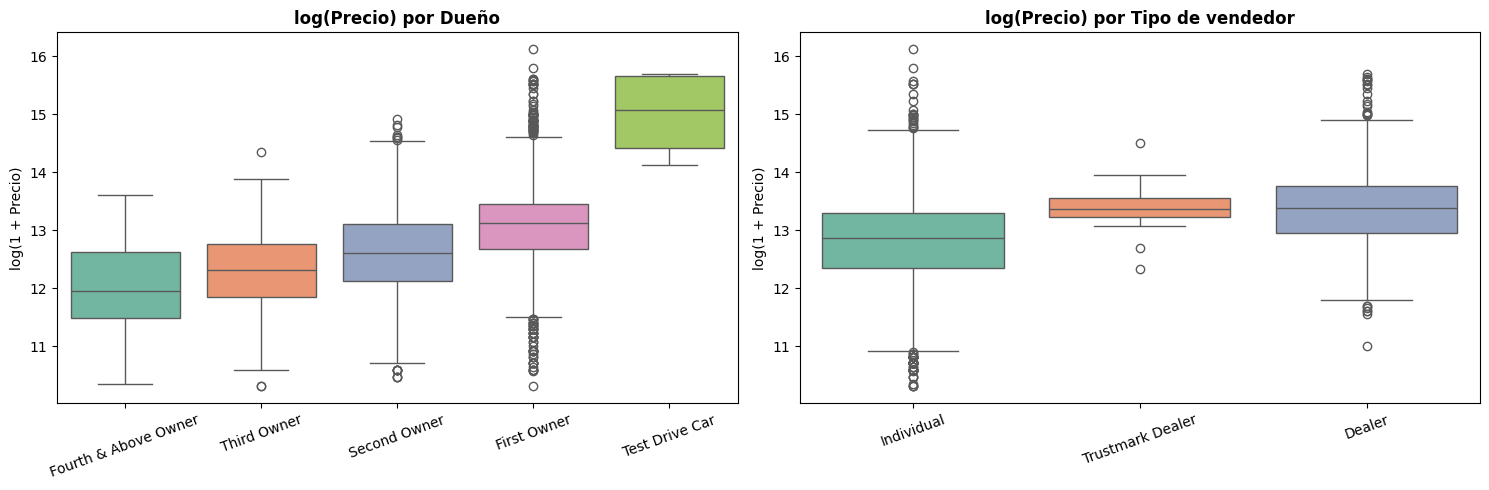

In [21]:
# ── 4. MICROCONTEXTO DE LA VENTA ──
log_price = np.log1p(df_train['selling_price'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cat_venta = [('owner', 'Dueño'), ('seller_type', 'Tipo de vendedor')]

for ax, (col, titulo) in zip(axes, cat_venta):
    orden = df_train.groupby(col)['selling_price'].median().sort_values().index
    sns.boxplot(data=df_train.assign(log_price=log_price),
                x=col, y='log_price', order=orden, hue=col, hue_order=orden,
                ax=ax, palette='Set2', legend=False)
    ax.set_title(f'log(Precio) por {titulo}', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('log(1 + Precio)')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 5. Macrocontexto de la venta
Variables del contexto comercial de la operación: `year`.

Pero year no contiene información en sí. 
Se cargan datos macroeconómicos para esos años.

In [22]:
macro_india = pd.read_csv("dataset/india_macro_1980_2020_inflation_real_gdp_growth.csv")
macro_india.head()

,year,country,currency,inflation_annual_pct,real_gdp_growth_annual_pct
0,1980,India,INR,11.346073,6.735822
1,1981,India,INR,13.112547,6.006204
2,1982,India,INR,7.890743,3.475733
3,1983,India,INR,11.868081,7.288893
4,1984,India,INR,8.318907,3.820738


**Fuente de los datos macroeconómicos:** Banco Mundial — *World Development Indicators* (WDI).
Indicadores utilizados para India (1980-2020):

- *Inflation, consumer prices (annual %)* — código `FP.CPI.TOTL.ZG`
  ([link](https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG?locations=IN))
- *GDP growth (annual %)* — código `NY.GDP.MKTP.KD.ZG`
  ([link](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG?locations=IN))

In [23]:
# ── Contexto macroeconómico de India en 2020 (marco de referencia del dataset) ──

macro_2020 = macro_india[macro_india['year'] == 2020].iloc[0]
inflacion_2020 = macro_2020['inflation_annual_pct']
pbi_2020 = macro_2020['real_gdp_growth_annual_pct']

# Promedios históricos como referencia
inflacion_prom = macro_india['inflation_annual_pct'].mean()
pbi_prom = macro_india['real_gdp_growth_annual_pct'].mean()

print("=" * 60)
print(f"  CONTEXTO MACROECONÓMICO — INDIA 2020")
print("=" * 60)
print(f"  Inflación anual         : {inflacion_2020:>6.2f}%   (promedio 1980-2020: {inflacion_prom:.2f}%)")
print(f"  Crecimiento real del PBI: {pbi_2020:>6.2f}%   (promedio 1980-2020: {pbi_prom:.2f}%)")
print("=" * 60)

  CONTEXTO MACROECONÓMICO — INDIA 2020
  Inflación anual         :   6.62%   (promedio 1980-2020: 7.74%)
  Crecimiento real del PBI:  -5.78%   (promedio 1980-2020: 5.81%)


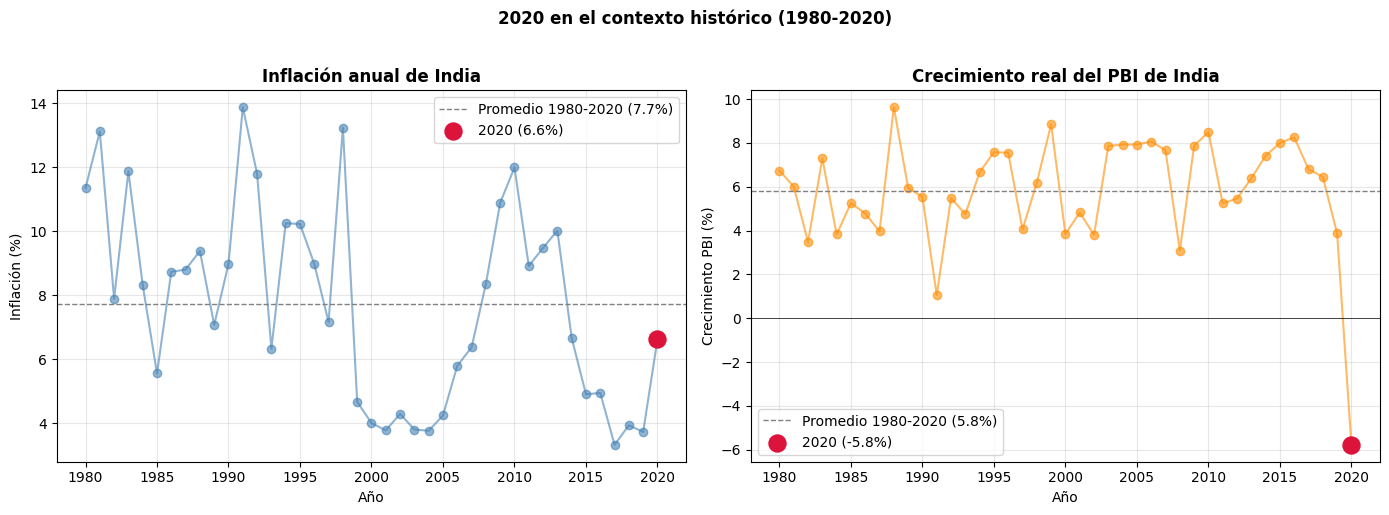

In [24]:
# ── Visualización: 2020 en su contexto histórico ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inflación
axes[0].plot(macro_india['year'], macro_india['inflation_annual_pct'],
             marker='o', color='steelblue', linewidth=1.5, alpha=0.6)
axes[0].axhline(inflacion_prom, color='gray', linestyle='--', linewidth=1,
                label=f'Promedio 1980-2020 ({inflacion_prom:.1f}%)')
# Destacar 2020
axes[0].scatter([2020], [inflacion_2020], color='crimson', s=150, zorder=5,
                label=f'2020 ({inflacion_2020:.1f}%)')
axes[0].set_title('Inflación anual de India', fontweight='bold')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Inflación (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# PBI
axes[1].plot(macro_india['year'], macro_india['real_gdp_growth_annual_pct'],
             marker='o', color='darkorange', linewidth=1.5, alpha=0.6)
axes[1].axhline(pbi_prom, color='gray', linestyle='--', linewidth=1,
                label=f'Promedio 1980-2020 ({pbi_prom:.1f}%)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].scatter([2020], [pbi_2020], color='crimson', s=150, zorder=5,
                label=f'2020 ({pbi_2020:.1f}%)')
axes[1].set_title('Crecimiento real del PBI de India', fontweight='bold')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Crecimiento PBI (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('2020 en el contexto histórico (1980-2020)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión del análisis macroeconómico:**

El año 2020 fue atípico para la economía india: el PBI se contrajo un 5.78% (frente a un promedio histórico de +5.8%) producto de la pandemia. Este contexto sitúa al dataset en un momento de mercado particular.

Sin embargo, estas variables **no se incorporan como features del modelo**, por dos razones:

1. Todo el dataset corresponde a un único corte temporal (ventas registradas en 2020), por lo que los indicadores macro toman el mismo valor en todas las filas: tienen **varianza nula** y no aportan poder predictivo.
2. Tampoco sería correcto unirlos por el *año de fabricación* del auto, ya que el precio de reventa responde al contexto económico del momento de la **venta** (2020), no al del año en que el vehículo fue fabricado.

En la descomposición planteada al inicio, este término macro (`z`) queda absorbido en el término de error `ε`: es real, pero constante y no observable a nivel de cada operación.

# 9. Faltantes

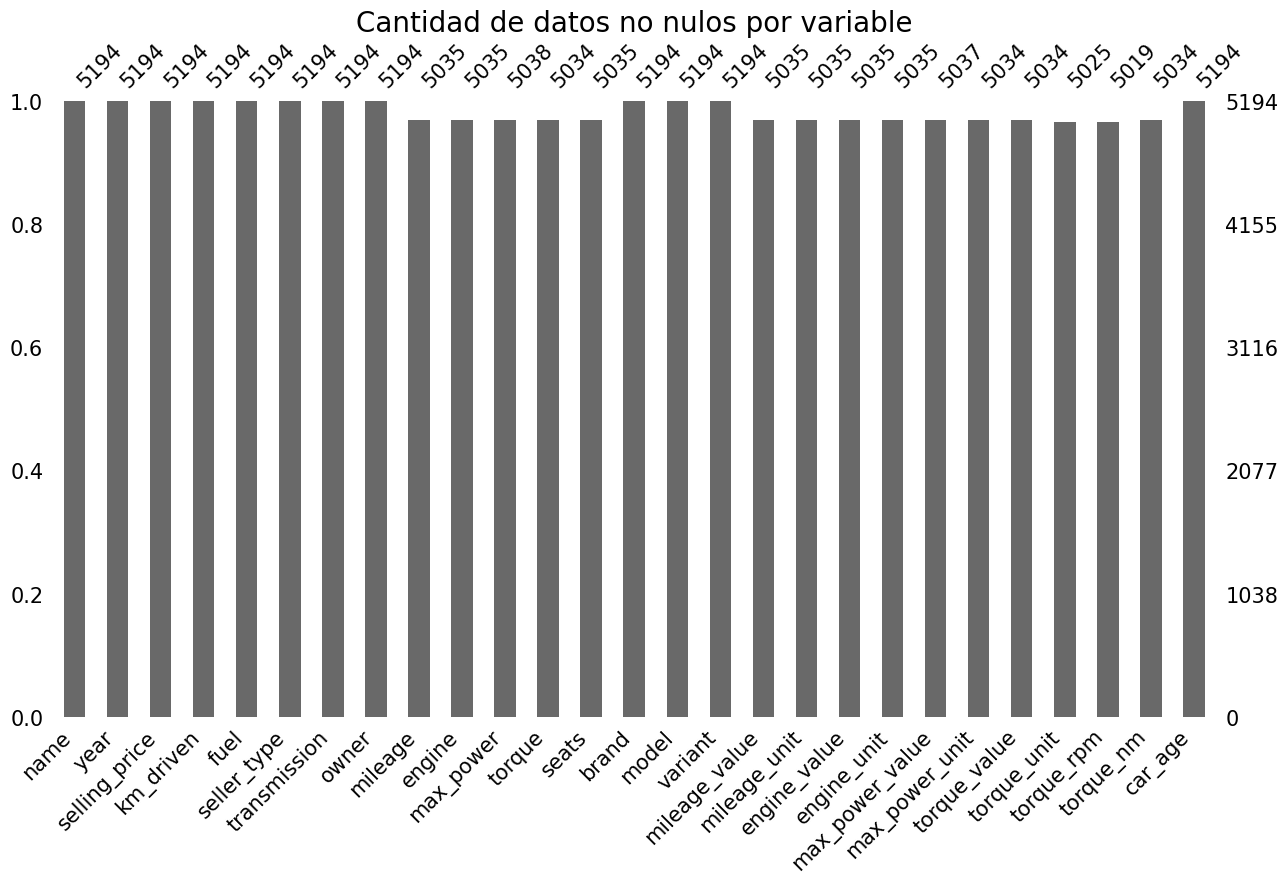

In [25]:
msno.bar(df_train, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

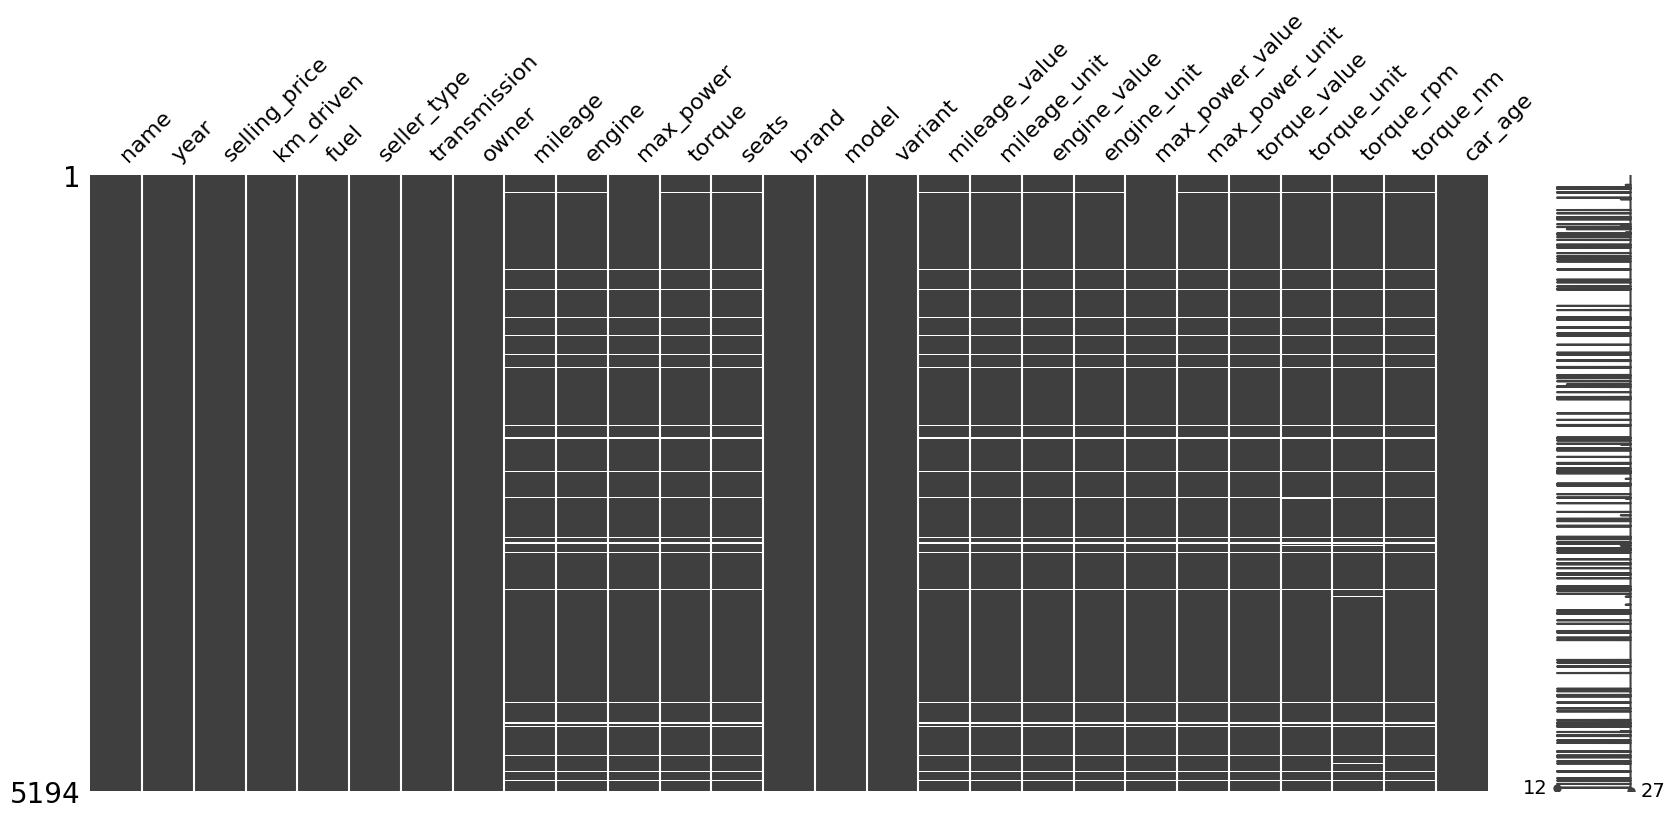

In [26]:
# Matriz de valores faltantes
msno.matrix(df_train, figsize=(20,8))

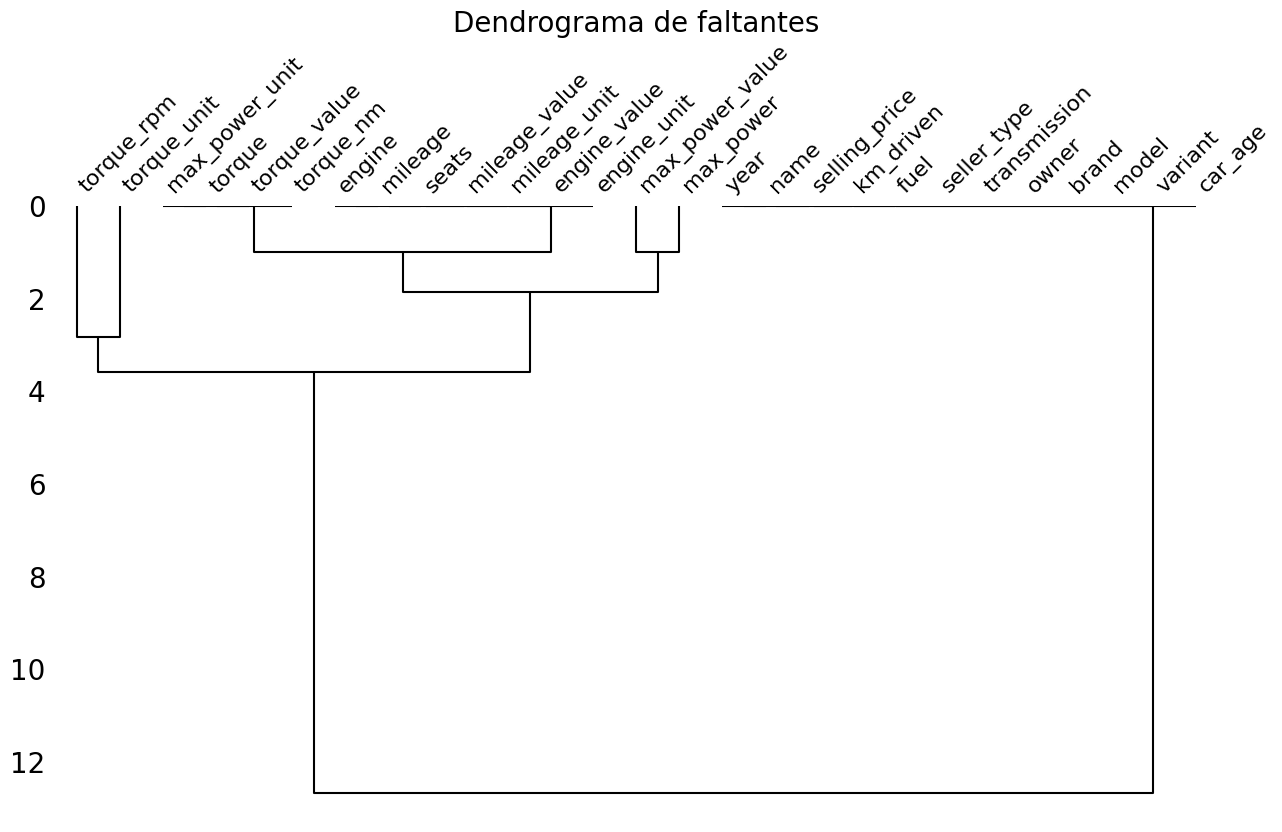

In [27]:

msno.dendrogram(df_train, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [28]:
# Columnas técnicas que tienen nulos
cols_nul = ['mileage', 'engine', 'max_power', 'torque', 'seats']

# Filas de train que tienen al menos un nulo en esas columnas
mask_nulos = df_train[cols_nul].isna().any(axis=1)

print(f"Filas con faltantes: {mask_nulos.sum()} de {len(df_train)} ({mask_nulos.sum()/len(df_train)*100:.1f}%)")
print()

# Comparar el año: filas CON nulo vs SIN nulo
print("Año promedio:")
print(f"  Filas CON faltante: {df_train[mask_nulos]['year'].mean():.1f}")
print(f"  Filas SIN faltante: {df_train[~mask_nulos]['year'].mean():.1f}")
print()

Filas con faltantes: 160 de 5194 (3.1%)

Año promedio:
  Filas CON faltante: 2007.2
  Filas SIN faltante: 2013.6



In [29]:
#  Mirar las filas con faltantes
df_faltantes = df_train[df_train.isna().any(axis=1)]
print(f"Filas con algún faltante: {len(df_faltantes)} de {len(df_train)}")
df_faltantes

Filas con algún faltante: 176 de 5194


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,model,variant,mileage_value,mileage_unit,engine_value,engine_unit,max_power_value,max_power_unit,torque_value,torque_unit,torque_rpm,torque_nm,car_age
3116,Tata Indigo TDI,2008,210000,100000,Diesel,Individual,Manual,First Owner,19.61 kmpl,1405 CC,70 bhp,135.4Nm@ 2500,5.0,Tata,Indigo,TDI,19.61,kmpl,1405.0,CC,70.0,bhp,135.4,Nm,NaN,135.4,12
6344,Maruti Swift VDI BSIV,2010,352000,72179,Diesel,Dealer,Manual,First Owner,NaN,NaN,NaN,NaN,NaN,Maruti,Swift,VDI BSIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
206,Maruti Omni E 8 Str STD,2003,40000,90000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN,Maruti,Omni,E 8 Str STD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17
2189,Fiat Punto 1.3 Emotion,2010,190000,120000,Diesel,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN,Fiat,Punto,1.3 Emotion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
314,Mahindra Willys CJ 3B 4X4,1983,300000,10000,Diesel,Individual,Manual,Third Owner,NaN,NaN,NaN,NaN,NaN,Mahindra,Willys,CJ 3B 4X4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629,Hyundai Santro Xing XG,2005,95000,125000,Petrol,Individual,Manual,Fourth & Above Owner,NaN,NaN,NaN,NaN,NaN,Hyundai,Santro,Xing XG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
200,Toyota Etios GD,2012,235000,120000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN,Toyota,Etios,GD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
6508,Maruti Swift 1.3 ZXI,2006,229999,110000,Petrol,Individual,Manual,Third Owner,NaN,NaN,NaN,NaN,NaN,Maruti,Swift,1.3 ZXI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
1055,Toyota Etios Liva GD,2012,300000,80000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN,Toyota,Etios,Liva GD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8


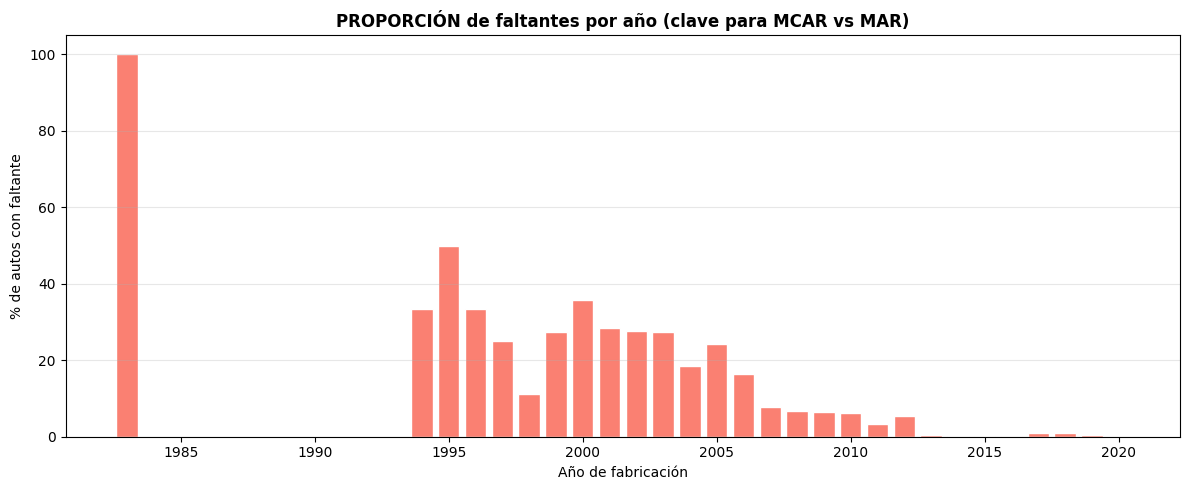

In [30]:
# df_faltantes ya lo tenés definido (filas con algún nulo)
df_train['tiene_faltante'] = df_train.isna().any(axis=1)

# Proporción de faltantes por año
prop = df_train.groupby('year')['tiene_faltante'].mean() * 100

plt.figure(figsize=(12, 5))
plt.bar(prop.index, prop.values, color='salmon', edgecolor='white')
plt.title('PROPORCIÓN de faltantes por año (clave para MCAR vs MAR)', fontweight='bold')
plt.xlabel('Año de fabricación')
plt.ylabel('% de autos con faltante')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [31]:
# ── Cuantificar el impacto antes de eliminar ──
cols_con_nulos = ['mileage_value', 'engine_value', 'max_power_value', 'torque_nm', 'seats']

mask_train = df_train[cols_con_nulos].isna().any(axis=1)
mask_test  = df_test[cols_con_nulos].isna().any(axis=1)

print(f"Train: {mask_train.sum()} de {len(df_train)} filas a eliminar ({mask_train.sum()/len(df_train)*100:.2f}%)")
print(f"Test : {mask_test.sum()} de {len(df_test)} filas a eliminar ({mask_test.sum()/len(df_test)*100:.2f}%)")

print(f"\nPrecio mediano filas A ELIMINAR (train): {df_train.loc[mask_train, 'selling_price'].median():>10,.0f} INR")
print(f"Precio mediano filas A CONSERVAR (train): {df_train.loc[~mask_train, 'selling_price'].median():>10,.0f} INR")
print(f"\nAño promedio filas A ELIMINAR (train): {df_train.loc[mask_train, 'year'].mean():.1f}")
print(f"Año promedio filas A CONSERVAR (train): {df_train.loc[~mask_train, 'year'].mean():.1f}")

Train: 160 de 5194 filas a eliminar (3.08%)
Test : 49 de 1732 filas a eliminar (2.83%)

Precio mediano filas A ELIMINAR (train):    177,500 INR
Precio mediano filas A CONSERVAR (train):    420,000 INR

Año promedio filas A ELIMINAR (train): 2007.2
Año promedio filas A CONSERVAR (train): 2013.6


In [32]:
# ── Eliminación de filas con nulos en variables técnicas ──
# Solo se aplica sobre train y test ya construidos. NO se toca df_raw.

cols_obligatorias = ['mileage_value', 'engine_value', 'max_power_value', 'torque_nm', 'seats']

n_train_antes = len(df_train)
n_test_antes  = len(df_test)

df_train = df_train.dropna(subset=cols_obligatorias).reset_index(drop=True)
df_test  = df_test.dropna(subset=cols_obligatorias).reset_index(drop=True)

print(f"Train: {n_train_antes:,} → {len(df_train):,} filas  (-{n_train_antes - len(df_train)})")
print(f"Test : {n_test_antes:,} → {len(df_test):,} filas  (-{n_test_antes - len(df_test)})")

# Verificación: no deberían quedar nulos en esas columnas
print(f"\nNulos restantes en train (cols técnicas): {df_train[cols_obligatorias].isna().sum().sum()}")
print(f"Nulos restantes en test  (cols técnicas): {df_test[cols_obligatorias].isna().sum().sum()}")

Train: 5,194 → 5,034 filas  (-160)
Test : 1,732 → 1,683 filas  (-49)

Nulos restantes en train (cols técnicas): 0
Nulos restantes en test  (cols técnicas): 0


# 10. Outliers

Tratamiento de outliers:

1) Criterio: km físicamente imposibles (>1.000.000 km).

2) Precio superior al 99% o menor al 1%.


In [33]:
UMBRAL_KM = 1_000_000

# Identificar los errores en TRAIN
errores_km = df_train['km_driven'] > UMBRAL_KM
print(f"Errores de km detectados en train: {errores_km.sum()}")
print(df_train[errores_km][['name','year','km_driven','selling_price']].to_string())

# Eliminar SOLO de train (el test se deja intacto)
df_train = df_train[~errores_km].copy()

print(f"\nFilas en train tras eliminar errores: {len(df_train):,}")

Errores de km detectados en train: 2
                        name  year  km_driven  selling_price
2780    Hyundai i20 Asta 1.2  2007    2360457         550000
4659  Mahindra XUV500 W6 2WD  2012    1500000         500000

Filas en train tras eliminar errores: 5,032


In [34]:
# ── Detección de extremos en precio (NO eliminación) ──
# Se reportan los percentiles 1 y 99 para tener contexto del rango.

p01 = df_train['selling_price'].quantile(0.01)
p99 = df_train['selling_price'].quantile(0.99)

extremos_bajos = df_train[df_train['selling_price'] <= p01]
extremos_altos = df_train[df_train['selling_price'] >= p99]

print(f"P1  precio: {p01:>12,.0f} INR  ({p01/1e5:.2f} Lakhs)")
print(f"P99 precio: {p99:>12,.0f} INR  ({p99/1e5:.2f} Lakhs)")
print(f"\nFilas en cola baja  (≤P1) : {len(extremos_bajos)}")
print(f"Filas en cola alta  (≥P99): {len(extremos_altos)}")

print("\n── Muestra de la cola baja ──")
print(extremos_bajos.nsmallest(5, 'selling_price')[
    ['name', 'year', 'km_driven', 'selling_price']].to_string(index=False))

print("\n── Muestra de la cola alta ──")
print(extremos_altos.nlargest(5, 'selling_price')[
    ['name', 'year', 'km_driven', 'selling_price']].to_string(index=False))

P1  precio:       55,000 INR  (0.55 Lakhs)
P99 precio:    2,642,250 INR  (26.42 Lakhs)

Filas en cola baja  (≤P1) : 60
Filas en cola alta  (≥P99): 51

── Muestra de la cola baja ──
               name  year  km_driven  selling_price
      Maruti 800 AC  1997      80000          29999
     Maruti Zen LXI  2001      10000          30000
     Maruti 800 Std  2000      56194          31000
Maruti 800 Std BSII  2003      35000          35000
      Maruti 800 AC  1998      40000          35000

── Muestra de la cola alta ──
                            name  year  km_driven  selling_price
   Volvo XC90 T8 Excellence BSIV  2017      30000       10000000
           BMW X7 xDrive 30d DPE  2020       5000        7200000
          Audi A6 35 TFSI Matrix  2019      23600        6523000
          Audi A6 35 TFSI Matrix  2019       7800        6223000
BMW 6 Series GT 630d Luxury Line  2018      28156        6000000


---

# 11. Transformación de columnas: Codificación y escalamiento


### Codificación de variables categóricas

Antes de modelar se transforman las variables categóricas en numéricas:

- **`owner` → `owner_num`** (ordinal): tiene un orden natural — más dueños implica más uso del vehículo — por lo que se codifica como número entero del 1 al 5.
- **`transmission` → `is_manual`** (binaria): toma valor 1 si es manual y 0 si es automática.
- **`seller_type` → `is_individual`** (binaria): 1 si el vendedor es particular, 0 si es concesionario.
- **`brand` → `brand_grouped`**: se conservan las 10 marcas más frecuentes en el dataset y el resto se agrupa bajo la etiqueta `Other`. Esto evita generar 32 columnas dispersas al hacer one-hot, lo cual perjudicaría especialmente a KNN y SVR.

La selección de las top 10 marcas se calcula **únicamente sobre el set de entrenamiento** y luego se aplica al test, para no introducir información del test en las decisiones de preprocesamiento.

In [35]:
# ── Codificación de variables categóricas ──

# Owner: ordinal (más dueños = más uso)
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5,
}
df_train['owner_num'] = df_train['owner'].map(owner_map)
df_test['owner_num']  = df_test['owner'].map(owner_map)

# Binarias
df_train['is_manual']     = (df_train['transmission'] == 'Manual').astype(int)
df_test['is_manual']      = (df_test['transmission']  == 'Manual').astype(int)

df_train['is_individual'] = (df_train['seller_type']  == 'Individual').astype(int)
df_test['is_individual']  = (df_test['seller_type']   == 'Individual').astype(int)

# Brand: top 10 + Other (calculado SOLO con train para evitar leakage)
top10_brands = df_train['brand'].value_counts().head(10).index.tolist()
df_train['brand_grouped'] = df_train['brand'].where(df_train['brand'].isin(top10_brands), 'Other')
df_test['brand_grouped']  = df_test['brand'].where(df_test['brand'].isin(top10_brands),  'Other')

print("Top 10 marcas (resto agrupado como 'Other'):")
print(top10_brands)



Top 10 marcas (resto agrupado como 'Other'):
['Maruti', 'Hyundai', 'Mahindra', 'Tata', 'Honda', 'Ford', 'Toyota', 'Chevrolet', 'Renault', 'Volkswagen']


### Armado de la matriz de features

Se aplica **one-hot encoding** a las dos variables categóricas restantes:

- **`fuel`**: se generan columnas binarias para cada tipo de combustible (Diesel, CNG, LPG, Electric), dejando Petrol como categoría de referencia (`drop_first=True`).
- **`brand_grouped`**: se generan columnas binarias para cada una de las top 10 marcas, dejando `Other` como categoría de referencia.

Dejar una categoría de referencia evita colinealidad perfecta entre las columnas dummies, lo cual es importante para los modelos lineales.

Se define luego la matriz **X** con todas las features (numéricas, binarias y dummies) y el vector **y** con el target transformado: `log(1 + selling_price)`. La transformación logarítmica del target — coherente con el análisis previo de asimetría — estabiliza la varianza y mejora el ajuste de todos los modelos.

Finalmente se alinean las columnas de train y test para garantizar que ambas matrices tengan exactamente las mismas features en el mismo orden.

In [36]:
# ── One-hot encoding ──
df_train_enc = pd.get_dummies(df_train, columns=['fuel', 'brand_grouped'],
                              drop_first=True, dtype=int)
df_test_enc  = pd.get_dummies(df_test,  columns=['fuel', 'brand_grouped'],
                              drop_first=True, dtype=int)

# ── Definir features finales ──
features_numericas = [
    'car_age', 'km_driven',
    'mileage_value', 'engine_value', 'max_power_value', 'torque_nm',
    'seats', 'owner_num',
]
features_binarias = ['is_manual', 'is_individual']
features_fuel  = [c for c in df_train_enc.columns if c.startswith('fuel_')]
features_brand = [c for c in df_train_enc.columns if c.startswith('brand_grouped_')]

all_features = features_numericas + features_binarias + features_fuel + features_brand

# ── Alinear columnas entre train y test ──
# Si alguna categoría no aparece en uno de los dos sets, agregar la columna con ceros
for col in all_features:
    if col not in df_test_enc.columns:
        df_test_enc[col] = 0
    if col not in df_train_enc.columns:
        df_train_enc[col] = 0



In [37]:
# ── Matrices finales ──
X_train = df_train_enc[all_features].copy()
X_test  = df_test_enc[all_features].copy()

# Target: log(1 + precio)
y_train = np.log1p(df_train['selling_price'].values)
y_test  = np.log1p(df_test['selling_price'].values)

# Guardamos también el precio original (lo necesitamos para evaluar en INR)
y_train_orig = df_train['selling_price'].values
y_test_orig  = df_test['selling_price'].values

# Verificación
print(f"Total de features: {len(all_features)}")
print(f"  • Numéricas:    {len(features_numericas)}")
print(f"  • Binarias:     {len(features_binarias)}")
print(f"  • Dummies fuel: {len(features_fuel)}")
print(f"  • Dummies brand:{len(features_brand)}")
print(f"\nShape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test : {y_test.shape}")

Total de features: 23
  • Numéricas:    8
  • Binarias:     2
  • Dummies fuel: 3
  • Dummies brand:10

Shape X_train: (5032, 23)
Shape X_test : (1683, 23)
Shape y_train: (5032,)
Shape y_test : (1683,)


### Escalado de variables numéricas

Los modelos basados en distancia (KNN) o en márgenes (SVR) son sensibles a la escala de las variables: una feature con valores en miles (como `km_driven`) dominaría sobre otra en decenas (como `car_age`). Para evitarlo, se aplica **`StandardScaler`** a las variables numéricas, que las transforma a media 0 y desvío estándar 1.

Decisiones clave:

- **El scaler se ajusta únicamente sobre train** (`fit_transform`) y luego se aplica a test (`transform`). De esta forma el test no influye en los parámetros de escalado, evitando data leakage.
- **Solo se escalan las features numéricas continuas**. Las binarias y dummies (0/1) no se escalan: ya están en una escala comparable y mantienen su interpretación.
- Se preparan **dos versiones del dataset**: una escalada (para Regresión Lineal, KNN, SVR) y una sin escalar (para árboles, que son invariantes a transformaciones monótonas).

In [38]:
# ── Escalado de variables numéricas ──
from sklearn.preprocessing import StandardScaler

# Versión sin escalar — para árboles
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()

# Versión escalada — para Regresión Lineal, KNN, SVR
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

sc = StandardScaler()
X_train_scaled[features_numericas] = sc.fit_transform(X_train[features_numericas])
X_test_scaled[features_numericas]  = sc.transform(X_test[features_numericas])

# Verificación: las numéricas en train deberían tener media ≈ 0 y std ≈ 1
print("Estadísticas de las variables numéricas (train escalado):")
print(X_train_scaled[features_numericas].describe().loc[['mean', 'std', 'min', 'max']].round(3))

print(f"\nShapes finales:")
print(f"  X_train_scaled: {X_train_scaled.shape}  | X_test_scaled: {X_test_scaled.shape}  (para Lineal, KNN, SVR)")
print(f"  X_train_tree:   {X_train_tree.shape}  | X_test_tree:   {X_test_tree.shape}  (para Árbol)")

Estadísticas de las variables numéricas (train escalado):
      car_age  km_driven  mileage_value  engine_value  max_power_value  torque_nm  seats  owner_num
mean    0.000     -0.000          0.000         0.000            0.000      0.000 -0.000      0.000
std     1.000      1.000          1.000         1.000            1.000      1.000  1.000      1.000
min    -1.649     -1.518         -4.774        -1.633           -1.721     -1.060 -3.470     -0.675
max     5.040      8.850          5.521         4.362            9.770     29.055  8.616      4.720

Shapes finales:
  X_train_scaled: (5032, 23)  | X_test_scaled: (1683, 23)  (para Lineal, KNN, SVR)
  X_train_tree:   (5032, 23)  | X_test_tree:   (1683, 23)  (para Árbol)


---

# 12. Entrenamiento y Comparación de Modelos

### Función de evaluación

Como el target se transformó con logaritmo, las predicciones de los modelos también vienen en escala logarítmica. Para que las métricas sean **interpretables en INR**, se aplica `np.expm1()` para revertir la transformación antes de calcular los errores.

Se reportan cuatro métricas, alineadas con las que se usan en la materia:

- **R²**: fracción de la varianza del precio explicada por el modelo. Va de 0 a 1 (más alto, mejor).
- **MAE** (Mean Absolute Error): error absoluto medio en INR. Es la métrica más interpretable: "el modelo se equivoca en promedio en X rupias".
- **RMSE** (Root Mean Squared Error): penaliza más fuerte los errores grandes.
- **MAPE** (Mean Absolute Percentage Error): error porcentual medio. Útil para comparar performance entre rangos de precio muy distintos.

In [39]:
# ── Función de evaluación reutilizable ──
from sklearn.metrics import (mean_absolute_error, r2_score,
                              root_mean_squared_error,
                              mean_absolute_percentage_error)

def evaluar_modelo(y_true_orig, y_pred_log, nombre_modelo=""):
    """
    Evalúa un modelo cuyas predicciones están en escala log.
    Revierte el log y calcula métricas en INR (escala original).

    Parámetros
    ----------
    y_true_orig : array, precios reales en INR
    y_pred_log  : array, predicciones del modelo en escala log
    nombre_modelo : str, nombre para mostrar

    Devuelve
    -------
    dict con las cuatro métricas
    """
    # Revertir transformación logarítmica
    y_pred = np.expm1(y_pred_log)

    # Métricas
    mae  = mean_absolute_error(y_true_orig, y_pred)
    rmse = root_mean_squared_error(y_true_orig, y_pred)
    mape = mean_absolute_percentage_error(y_true_orig, y_pred)
    r2   = r2_score(y_true_orig, y_pred)

    # Reporte
    if nombre_modelo:
        print(f"── {nombre_modelo} ──")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAE  : {mae:>12,.0f} INR  (~{mae/1e5:.2f} Lakhs)")
    print(f"  RMSE : {rmse:>12,.0f} INR  (~{rmse/1e5:.2f} Lakhs)")
    print(f"  MAPE : {mape*100:.2f}%")

    return {'modelo': nombre_modelo, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


# Diccionario donde vamos a ir guardando los resultados de cada modelo
resultados = {}

print("Función `evaluar_modelo` lista para usar.")
print("Los resultados de cada modelo se irán guardando en el diccionario `resultados`.")

Función `evaluar_modelo` lista para usar.
Los resultados de cada modelo se irán guardando en el diccionario `resultados`.


---

# 13. Modelo baseline: precio mediano por marca y antigüedad

Antes de entrenar modelos de machine learning, se construye un **modelo baseline heurístico** simple que servirá como piso de comparación. La idea es que cualquier modelo más sofisticado debería superar claramente este punto de partida; si no lo logra, no aporta valor real.

**Lógica del baseline:**

Para cada combinación `(brand, car_age)` presente en el set de entrenamiento, se calcula el **precio mediano** de los autos de esa marca y esa antigüedad. Al momento de predecir, se busca el grupo correspondiente y se devuelve esa mediana.

Si en test aparece una combinación que no existe en train (por ejemplo, una marca rara con una antigüedad específica no observada en entrenamiento), se hacen dos *fallbacks* progresivos:
1. Usar el mediano de la marca (sin condicionar por antigüedad).
2. Si la marca tampoco existe en train, usar el mediano global del dataset.

Se usa la **mediana** y no la media porque es más robusta a outliers (Maserati, Audi A6, etc.) y representa mejor el "auto típico" de cada grupo. Es un modelo muy simple pero captura las dos variables más informativas: marca y edad.

In [40]:
# ── Modelo baseline: precio mediano por (brand, car_age) ──

# Diccionarios precalculados desde TRAIN (no se mira test en ningún momento)
mediana_por_brand_age = df_train.groupby(['brand', 'car_age'])['selling_price'].median().to_dict()
mediana_por_brand     = df_train.groupby('brand')['selling_price'].median().to_dict()
mediana_global        = df_train['selling_price'].median()

def predecir_baseline(brand, car_age):
    """Devuelve el precio mediano para (brand, car_age), con fallbacks."""
    if (brand, car_age) in mediana_por_brand_age:
        return mediana_por_brand_age[(brand, car_age)]
    if brand in mediana_por_brand:
        return mediana_por_brand[brand]
    return mediana_global

# Predicciones sobre TEST
y_pred_baseline = np.array([
    predecir_baseline(b, a)
    for b, a in zip(df_test['brand'].values, df_test['car_age'].values)
])

# Como el baseline predice precios directamente en INR (no en log),
# pasamos a log para usar la misma función evaluar_modelo que el resto
y_pred_baseline_log = np.log1p(y_pred_baseline)

print(f"Combinaciones (brand, car_age) en train: {len(mediana_por_brand_age):,}")
print(f"Marcas únicas en train: {len(mediana_por_brand)}")
print(f"Mediana global de precio en train: {mediana_global:,.0f} INR\n")

resultados['Baseline'] = evaluar_modelo(y_test_orig, y_pred_baseline_log, "Baseline (mediana brand+age)")

Combinaciones (brand, car_age) en train: 276
Marcas únicas en train: 31
Mediana global de precio en train: 420,000 INR

── Baseline (mediana brand+age) ──
  R²   : 0.6887
  MAE  :      163,550 INR  (~1.64 Lakhs)
  RMSE :      296,239 INR  (~2.96 Lakhs)
  MAPE : 35.15%


**Comentario:**
Este baseline es la referencia mínima. Cualquier modelo de ML que probemos a continuación debería superar estas métricas — en particular, debería lograr un R² claramente mayor y un MAPE menor. Si un modelo sofisticado no le gana al baseline, está agregando complejidad sin valor.

---

# 14. Regresión Lineal y Ridge

Los modelos lineales asumen que el precio (en escala log) es una combinación lineal de las features:

$$\log(1 + \text{precio}) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

Es el modelo más simple e interpretable. Se entrenan dos variantes:

- **Regresión Lineal**: sin regularización, ajusta los coeficientes minimizando el error cuadrático.
- **Ridge**: agrega una penalidad L2 sobre la magnitud de los coeficientes, controlada por el hiperparámetro `alpha`. Mitiga el efecto de la **multicolinealidad** entre features (recordemos que `engine_value`, `max_power_value` y `torque_nm` están físicamente relacionadas) e impide que algún coeficiente individual crezca desmesuradamente.

Para Ridge se hace **búsqueda de grilla con validación cruzada (5-fold)** sobre `alpha`, optimizando MAE.

Ambos modelos usan el dataset **escalado** (`X_train_scaled`), ya que sin escalado la penalidad de Ridge afectaría desproporcionadamente a las features de mayor magnitud.

In [41]:
# ── Regresión Lineal ──

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_log = lr.predict(X_test_scaled)

resultados['Regresión Lineal'] = evaluar_modelo(
    y_test_orig, y_pred_lr_log, "Regresión Lineal"
)

── Regresión Lineal ──
  R²   : 0.8044
  MAE  :      101,933 INR  (~1.02 Lakhs)
  RMSE :      234,818 INR  (~2.35 Lakhs)
  MAPE : 20.54%


In [42]:
# ── Ridge con búsqueda de hiperparámetro ──

ridge = Ridge(random_state=42)

grid = GridSearchCV(
    ridge,
    {"alpha": np.linspace(0.01, 20, 200)},
    refit=True,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print(f"Mejor alpha: {grid.best_params_['alpha']:.3f}")
print(f"MAE CV (log): {-grid.best_score_:.4f}\n")

# Mejor modelo entrenado
ridge_best = grid.best_estimator_
y_pred_ridge_log = ridge_best.predict(X_test_scaled)

resultados['Ridge'] = evaluar_modelo(y_test_orig, y_pred_ridge_log, "Ridge")

Mejor alpha: 0.010
MAE CV (log): 0.1959

── Ridge ──
  R²   : 0.8044
  MAE  :      101,933 INR  (~1.02 Lakhs)
  RMSE :      234,819 INR  (~2.35 Lakhs)
  MAPE : 20.54%


**Comentario:**
Tanto la Regresión Lineal como Ridge logran un R² claramente superior al baseline, mostrando que las features técnicas (motor, potencia, torque, antigüedad) aportan información valiosa más allá de marca y edad. La diferencia entre Lineal y Ridge suele ser mínima cuando hay suficientes datos, pero Ridge es la versión más prolija desde el punto de vista metodológico por su control sobre la multicolinealidad.

Aun así, ambos modelos comparten una limitación de fondo: **asumen relaciones lineales**. La relación entre antigüedad y precio (depreciación) y entre kilometraje y precio no son lineales, por lo que se espera que modelos más flexibles (KNN, SVR, árbol) las superen.

**Observaciones:**

- **Regresión Lineal vs Baseline**: el R² sube de 0.69 a 0.80 (+11 puntos) y el MAPE cae de 35% a 20%. Esto muestra que las features técnicas (potencia, motor, km, torque) aportan poder predictivo real más allá de `(brand, car_age)`.
- **Ridge ≈ Regresión Lineal**: el alpha óptimo (0.01) es prácticamente cero, lo que indica que la regularización no aporta mejora. La multicolinealidad entre las variables técnicas, aunque presente, no genera inestabilidad gracias al tamaño del dataset (~5.000 filas en train).
- Ambos modelos lineales tienen como techo R²≈0.80. Para superarlo se necesita capturar **relaciones no lineales** (depreciación, interacciones entre features), lo cual es justamente lo que pueden hacer KNN, SVR, el árbol y los ensambles.

---

# 15. K-Nearest Neighbors (KNN)

KNN predice el precio de un auto buscando los **K vecinos más cercanos** en el espacio de features y promediando sus precios. No asume ninguna forma funcional (lineal o no), por lo que puede capturar relaciones complejas. Su desempeño depende fuertemente de:

- **`n_neighbors`**: cantidad de vecinos a considerar. Pocos vecinos → modelo sobreajustado; muchos vecinos → predicciones demasiado suavizadas.
- **`weights`**: si se promedian los vecinos uniformemente o ponderados por distancia (los más cercanos pesan más).
- **`p`**: parámetro de la distancia de Minkowski (p=1 → Manhattan, p=2 → Euclidiana).

Es crítico que las variables estén **escaladas** (lo cual ya hicimos), ya que KNN calcula distancias y sin escalado las features de mayor magnitud dominarían el cálculo.

Se hace búsqueda de grilla con validación cruzada 5-fold sobre estos tres hiperparámetros.

In [43]:
# ── KNN con búsqueda de hiperparámetros ──
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_jobs=-1)

hyperparams = {
    "n_neighbors": [3, 5, 7, 10, 15, 20, 30],
    "weights":     ["uniform", "distance"],
    "p":           [1, 2],                   # 1 = Manhattan, 2 = Euclidiana
}

grid = GridSearchCV(
    knn,
    hyperparams,
    refit=True,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {grid.best_params_}")
print(f"MAE CV (log): {-grid.best_score_:.4f}\n")

# Mejor modelo
knn_best = grid.best_estimator_
y_pred_knn_log = knn_best.predict(X_test_scaled)

resultados['KNN'] = evaluar_modelo(y_test_orig, y_pred_knn_log, "KNN")

Mejores parámetros: {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
MAE CV (log): 0.1803

── KNN ──
  R²   : 0.9110
  MAE  :       84,257 INR  (~0.84 Lakhs)
  RMSE :      158,413 INR  (~1.58 Lakhs)
  MAPE : 18.30%


**Observaciones:**

- **Salto respecto a los lineales**: el MAE cae de 102k a 84k INR (~17% de mejora) y el R² sube de 0.80 a 0.91. Esto confirma que la relación entre features y precio tiene un componente **no lineal**.
- **`weights='distance'`** indica que los vecinos más cercanos son los más informativos, no todos por igual. Es coherente con la idea de que autos muy similares tienen precios muy similares.
- **`p=1` (Manhattan)** funciona mejor que la distancia Euclidiana. Esto es esperable en espacios de relativa alta dimensionalidad (23 features), donde Manhattan suele discriminar mejor que Euclidiana.
- KNN mejora claramente sobre los modelos lineales, pero más adelante los ensambles de árboles (Random Forest, XGBoost, LightGBM) lo superan: parte de lo que KNN no captura son interacciones complejas entre variables que los ensambles modelan mejor.

---

# 16. Support Vector Regression (SVR)

SVR busca el hiperplano que mejor ajuste a los datos dentro de un margen de tolerancia ε, y mediante el truco del kernel puede modelar relaciones no lineales sin transformar explícitamente las features. Sus hiperparámetros principales:

- **`kernel`**: tipo de función kernel (`linear`, `rbf`, `poly`). RBF es la más flexible y suele ser la mejor opción para problemas no lineales.
- **`C`**: penalización por error. Valores altos → modelo más complejo, menos regularizado; valores bajos → modelo más simple, más regularizado.
- **`gamma`** (solo para RBF y poly): controla el "radio de influencia" de cada punto de entrenamiento. Valores altos → ajuste muy local; bajos → ajuste suave.
- **`epsilon`**: ancho del margen de tolerancia (errores menores a ε no se penalizan).

Como en KNN, SVR es sensible a la escala de features, por lo que se usa el dataset escalado.

**Nota sobre el tiempo de cómputo**: SVR escala desfavorablemente con el tamaño del dataset (entre O(n²) y O(n³)). Con ~6.000 filas y validación cruzada de 5-fold, el GridSearch toma varios minutos.

In [43]:
# ── SVR con búsqueda de hiperparámetros ──

svr = SVR()

# Hiperparametros
hyperparams = [
    {"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},
    {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf", "sigmoid"]},
    {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["poly"]},
]

grid = GridSearchCV(
    svr,
    hyperparams,
    refit=True,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

t0 = time.time()
grid.fit(X_train_scaled, y_train)
print(f"Tiempo de búsqueda: {(time.time() - t0)/60:.1f} min\n")

print(f"Mejores parámetros: {grid.best_params_}")
print(f"MAE CV (log): {-grid.best_score_:.4f}\n")

# Mejor modelo
svr_best = grid.best_estimator_
y_pred_svr_log = svr_best.predict(X_test_scaled)

resultados['SVR'] = evaluar_modelo(y_test_orig, y_pred_svr_log, "SVR")

Tiempo de búsqueda: 12.1 min

Mejores parámetros: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
MAE CV (log): 0.1648

── SVR ──
  R²   : 0.8992
  MAE  :       78,913 INR  (~0.79 Lakhs)
  RMSE :      168,607 INR  (~1.69 Lakhs)
  MAPE : 16.55%


**Observaciones:**

- **SVR mejora respecto a los modelos lineales** (R² 0.80 → 0.90), confirmando una vez más que la relación es no lineal.
- **SVR y KNN quedan parejos, pero con perfiles distintos**: SVR logra mejor MAE (79k vs 84k) y MAPE (16.5% vs 18.3%), mientras que KNN tiene mejor R² (0.91 vs 0.90) y RMSE (158k vs 169k). El RMSE alto de SVR frente a su buen MAE indica que comete **algunos errores grandes en casos extremos** (autos premium o muy baratos, donde el kernel RBF extrapola con dificultad), aunque en el caso típico es muy preciso.
- **`C=1` y `gamma=0.1`** indica que el modelo eligió una configuración conservadora, sin necesidad de gran complejidad, algo razonable con ~5.000 filas que ya restringen bien el problema.
- Tanto SVR como KNN quedan por debajo de los métodos de ensamble, que capturan mejor las interacciones entre variables.

---

# 17. Árbol de regresión

Un árbol de regresión segmenta recursivamente el espacio de features mediante umbrales que minimizan el error cuadrático dentro de cada partición. Genera reglas de decisión interpretables del tipo: *"si potencia > 100 bhp y antigüedad < 5 años, entonces precio ≈ X"*.

**Características clave:**

- **No requiere escalado**: los árboles parten por umbrales, por lo que son invariantes a transformaciones monótonas. Se usa `X_train_tree` (sin escalar).
- **Captura no linealidades e interacciones** sin necesidad de especificarlas explícitamente.
- **Tiende al sobreajuste** si crece sin restricciones: un árbol que se expande hasta tener una hoja por observación memoriza el train con error casi nulo, pero generaliza mal.

Para evitar sobreajuste se exploran dos enfoques:

1. **Árbol sin restricciones** (referencia inicial): muestra el sobreajuste.
2. **Búsqueda de hiperparámetros con Optuna**: ajusta `max_depth`, `min_samples_split`, `min_samples_leaf` y `ccp_alpha` (poda por costo-complejidad).

In [44]:
# ── Árbol sin restricciones (referencia inicial) ──
tree_baseline = DecisionTreeRegressor(random_state=42)
tree_baseline.fit(X_train_tree, y_train)

# Evaluamos en train y test para evidenciar el sobreajuste
y_pred_train_log = tree_baseline.predict(X_train_tree)
y_pred_test_log  = tree_baseline.predict(X_test_tree)

mae_train = mean_absolute_error(np.expm1(y_train), np.expm1(y_pred_train_log))
mae_test  = mean_absolute_error(y_test_orig, np.expm1(y_pred_test_log))

print("Árbol sin restricciones (referencia inicial):")
print(f"  MAE train: {mae_train:>12,.0f} INR")
print(f"  MAE test : {mae_test:>12,.0f} INR")
print(f"  Profundidad del árbol: {tree_baseline.get_depth()}")
print(f"  Hojas: {tree_baseline.get_n_leaves()}")
print("\nSi el MAE en train es mucho menor al de test → sobreajuste.")

Árbol sin restricciones (referencia inicial):
  MAE train:        3,230 INR
  MAE test :       94,265 INR
  Profundidad del árbol: 29
  Hojas: 4540

Si el MAE en train es mucho menor al de test → sobreajuste.


### Optimización de hiperparámetros con Optuna

Se hace búsqueda de hiperparámetros usando **Optuna**, framework basado en optimización bayesiana que explora el espacio de forma más eficiente que una búsqueda de grilla exhaustiva. Los hiperparámetros que se ajustan son:

- **`max_depth`**: profundidad máxima del árbol (controla complejidad).
- **`min_samples_split`**: mínimo de muestras para dividir un nodo.
- **`min_samples_leaf`**: mínimo de muestras en cada hoja.
- **`ccp_alpha`**: parámetro de poda por costo-complejidad (mayor α → más poda).

Se evalúa cada combinación con validación cruzada 5-fold, maximizando `-MAE` en escala log.

In [47]:
# ── Optimización del árbol con Optuna ──
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth         = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 20)
    ccp_alpha         = trial.suggest_float("ccp_alpha", 0.0, 0.05)

    tree = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        ccp_alpha=ccp_alpha,
        random_state=42,
    )
    score = cross_val_score(tree, X_train_tree, y_train,
                             cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    return score.mean()


def champion_callback(study, frozen_trial):
    """Imprime solo cuando se encuentra un nuevo mejor trial."""
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(f"Trial {frozen_trial.number} → {frozen_trial.value:.4f} "
                  f"(mejora {improvement_percent:.2f}%)")
        else:
            print(f"Trial inicial {frozen_trial.number} → {frozen_trial.value:.4f}")


# Estudio
optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, callbacks=[champion_callback])

print(f"\nMejores hiperparámetros: {study.best_params}")
print(f"MAE CV (log): {-study.best_value:.4f}")

Trial inicial 0 → -0.3439
Trial 3 → -0.2993 (mejora -14.91%)
Trial 7 → -0.2970 (mejora -0.77%)
Trial 10 → -0.2247 (mejora -32.16%)
Trial 11 → -0.2158 (mejora -4.11%)
Trial 12 → -0.2094 (mejora -3.09%)
Trial 19 → -0.2040 (mejora -2.65%)
Trial 21 → -0.1970 (mejora -3.53%)
Trial 41 → -0.1896 (mejora -3.90%)
Trial 46 → -0.1884 (mejora -0.61%)
Trial 58 → -0.1876 (mejora -0.46%)
Trial 63 → -0.1875 (mejora -0.06%)
Trial 71 → -0.1866 (mejora -0.45%)
Trial 97 → -0.1859 (mejora -0.41%)
Trial 160 → -0.1857 (mejora -0.12%)

Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 8, 'ccp_alpha': 2.8702849599603307e-05}
MAE CV (log): 0.1857


In [48]:
# ── Evaluación del árbol óptimo ──
tree_best = DecisionTreeRegressor(**study.best_params, random_state=42)
tree_best.fit(X_train_tree, y_train)

y_pred_tree_log = tree_best.predict(X_test_tree)

print(f"Profundidad del árbol final: {tree_best.get_depth()}")
print(f"Hojas: {tree_best.get_n_leaves()}\n")

resultados['Árbol'] = evaluar_modelo(y_test_orig, y_pred_tree_log, "Árbol de regresión")

Profundidad del árbol final: 16
Hojas: 298

── Árbol de regresión ──
  R²   : 0.9084
  MAE  :       88,776 INR  (~0.89 Lakhs)
  RMSE :      160,689 INR  (~1.61 Lakhs)
  MAPE : 18.96%


**Observaciones:**

- El árbol optimizado pasó de **4.540 hojas** (árbol sin restricciones, profundidad 29) a **298 hojas** (profundidad 16): un árbol unas **15× más compacto**, y con un MAE de test que incluso mejoró levemente (94k → 89k INR). Esto evidencia el efecto del control de sobreajuste.
- El control vino sobre todo de `min_samples_leaf=8` y `min_samples_split=9`. Si bien el `max_depth` óptimo fue 20, el árbol se detuvo por sí solo en profundidad 16, por lo que ese tope no fue la restricción determinante.
- `ccp_alpha` resultó prácticamente nulo (≈3×10⁻⁵): la poda por costo-complejidad no aportó mejora adicional, el control vino por los otros hiperparámetros.
- Con R² = 0.908, el árbol supera a los modelos lineales en todas las métricas y al SVR en R² y RMSE (aunque SVR logra mejor MAE y MAPE). Sin embargo, queda por debajo de KNN y, sobre todo, de los tres ensambles (Random Forest, XGBoost, LightGBM), que se construyen justamente combinando muchos árboles como este.
- Una ventaja conceptual del árbol es su **interpretabilidad**: cada predicción se puede trazar como una secuencia de reglas (`if potencia > X and antigüedad < Y → precio ≈ Z`), algo que los ensambles pierden al combinar cientos de árboles.

----------
# 18. Random Forest  (Bagging)


In [49]:
def objective_rf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 600, step=50),
        "max_depth":         trial.suggest_int("max_depth", 8, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 1.0]),
    }
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    # cv con n_jobs=1: el paralelismo ya lo aporta el propio RF (evita sobre-suscripción)
    score = cross_val_score(rf, X_train_tree, y_train,
                            cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
    return score.mean()


study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=40, callbacks=[champion_callback])

print(f"\nMejores hiperparámetros RF: {study_rf.best_params}")
print(f"MAE CV (log): {-study_rf.best_value:.4f}")


Trial inicial 0 → -0.1651
Trial 3 → -0.1624 (mejora -1.64%)
Trial 7 → -0.1607 (mejora -1.04%)
Trial 12 → -0.1596 (mejora -0.70%)
Trial 13 → -0.1595 (mejora -0.06%)
Trial 15 → -0.1562 (mejora -2.14%)
Trial 26 → -0.1559 (mejora -0.16%)

Mejores hiperparámetros RF: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.5}
MAE CV (log): 0.1559


In [50]:
rf_best = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_tree, y_train)

y_pred_rf_log = rf_best.predict(X_test_tree)
resultados["Random Forest"] = evaluar_modelo(y_test_orig, y_pred_rf_log, "Random Forest")

── Random Forest ──
  R²   : 0.9289
  MAE  :       74,743 INR  (~0.75 Lakhs)
  RMSE :      141,523 INR  (~1.42 Lakhs)
  MAPE : 16.02%


**Observaciones:**

- Random Forest alcanza R²=0.929 y supera claramente al árbol único (0.908 → 0.929): promediar muchos árboles descorrelacionados reduce la varianza, tal como predice la teoría de bagging.

- El mejor max_features fue 0.5 (no sqrt): el modelo prefirió considerar la mitad de los atributos en cada nodo, lo que descorrelaciona los árboles sin restringir tanto como √p.

- Es el más débil de los tres ensambles, pero queda por encima de KNN, SVR y el árbol en todas las métricas.

-----------
# 19. XGBOOST  (Gradient Boosting)

In [51]:
def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=50),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    xgb = XGBRegressor(**params, random_state=42, n_jobs=-1,
                       objective="reg:squarederror", tree_method="hist")
    score = cross_val_score(xgb, X_train_tree, y_train,
                            cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
    return score.mean()


study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, callbacks=[champion_callback])

print(f"\nMejores hiperparámetros XGBoost: {study_xgb.best_params}")
print(f"MAE CV (log): {-study_xgb.best_value:.4f}")

Trial inicial 0 → -0.1664
Trial 1 → -0.1559 (mejora -6.74%)
Trial 2 → -0.1547 (mejora -0.75%)
Trial 12 → -0.1541 (mejora -0.42%)
Trial 14 → -0.1521 (mejora -1.32%)
Trial 41 → -0.1520 (mejora -0.02%)

Mejores hiperparámetros XGBoost: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.029282661153638836, 'subsample': 0.6293325134244591, 'colsample_bytree': 0.701705840244853, 'min_child_weight': 3, 'reg_alpha': 0.0037885398710451757, 'reg_lambda': 0.0297461112545255}
MAE CV (log): 0.1520


In [50]:
xgb_best = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1,
                        objective="reg:squarederror", tree_method="hist")
xgb_best.fit(X_train_tree, y_train)

y_pred_xgb_log = xgb_best.predict(X_test_tree)
resultados["XGBoost"] = evaluar_modelo(y_test_orig, y_pred_xgb_log, "XGBoost")

── XGBoost ──
  R²   : 0.9372
  MAE  :       72,408 INR  (~0.72 Lakhs)
  RMSE :      133,079 INR  (~1.33 Lakhs)
  MAPE : 15.69%


**Observaciones:**

- XGBoost es el mejor modelo del trabajo: gana en las cuatro métricas (R²=0.937, MAE=72k, RMSE=133k, MAPE=15.7%).

- Sus hiperparámetros óptimos describen un boosting de manual: árboles poco profundos (max_depth=5), tasa de aprendizaje baja (≈0.05), 400 árboles y submuestreo de filas y columnas (~0.66 y 0.79). Es decir, muchos weak learners que corrigen errores de a poco.

- Que el boosting (corrección secuencial del error) le gane al bagging (Random Forest) es coherente: en datos tabulares estructurados como estos, suele ser el enfoque más fuerte.

-------------
# 20.  LIGHTGBM  (Gradient Boosting)

In [51]:
def objective_lgbm(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=50),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    lgbm = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    score = cross_val_score(lgbm, X_train_tree, y_train,
                            cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
    return score.mean()


study_lgbm = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=50, callbacks=[champion_callback])

print(f"\nMejores hiperparámetros LightGBM: {study_lgbm.best_params}")
print(f"MAE CV (log): {-study_lgbm.best_value:.4f}")


Trial inicial 0 → -0.1571
Trial 12 → -0.1549 (mejora -1.43%)
Trial 13 → -0.1544 (mejora -0.34%)
Trial 16 → -0.1537 (mejora -0.41%)
Trial 28 → -0.1533 (mejora -0.25%)
Trial 48 → -0.1533 (mejora -0.01%)

Mejores hiperparámetros LightGBM: {'n_estimators': 1000, 'num_leaves': 71, 'max_depth': 4, 'learning_rate': 0.11320382236815565, 'subsample': 0.6958673610570538, 'colsample_bytree': 0.6833051846434706, 'min_child_samples': 42, 'reg_alpha': 0.00355886251416247, 'reg_lambda': 0.004189834943060302}
MAE CV (log): 0.1533


In [52]:
lgbm_best = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1, importance_type="gain")
lgbm_best.fit(X_train_tree, y_train)

y_pred_lgbm_log = lgbm_best.predict(X_test_tree)
resultados["LightGBM"] = evaluar_modelo(y_test_orig, y_pred_lgbm_log, "LightGBM")

── LightGBM ──
  R²   : 0.9342
  MAE  :       73,058 INR  (~0.73 Lakhs)
  RMSE :      136,170 INR  (~1.36 Lakhs)
  MAPE : 15.74%


**Observaciones:**

- LightGBM queda prácticamente empatado con XGBoost (R²=0.934 vs 0.937; la diferencia está dentro del ruido). Es esperable: son la misma familia (gradient boosting de árboles), y difieren sobre todo en la implementación.

- Su configuración óptima refleja el crecimiento leaf-wise: max_depth bajo (4) pero num_leaves alto (71), con 1000 árboles y tasa de aprendizaje ≈0.11.

- Ventaja práctica frente a XGBoost: suele ser más rápido de entrenar, a igualdad de performance.

---------
# 21.  Importancia de atributos por modelo de ensamble

Top 10 features más importantes (promedio de los tres ensambles):

                      Random Forest  XGBoost  LightGBM  promedio
feature                                                         
car_age                      0.3682   0.1845    0.2656    0.2728
max_power_value              0.2597   0.1368    0.2971    0.2312
torque_nm                    0.1671   0.1271    0.2051    0.1664
engine_value                 0.0678   0.0535    0.0442    0.0552
is_manual                    0.0129   0.1105    0.0135    0.0456
mileage_value                0.0281   0.0152    0.0525    0.0319
brand_grouped_Tata           0.0107   0.0594    0.0139    0.0280
km_driven                    0.0278   0.0121    0.0440    0.0280
owner_num                    0.0158   0.0306    0.0316    0.0260
brand_grouped_Toyota         0.0064   0.0529    0.0082    0.0225


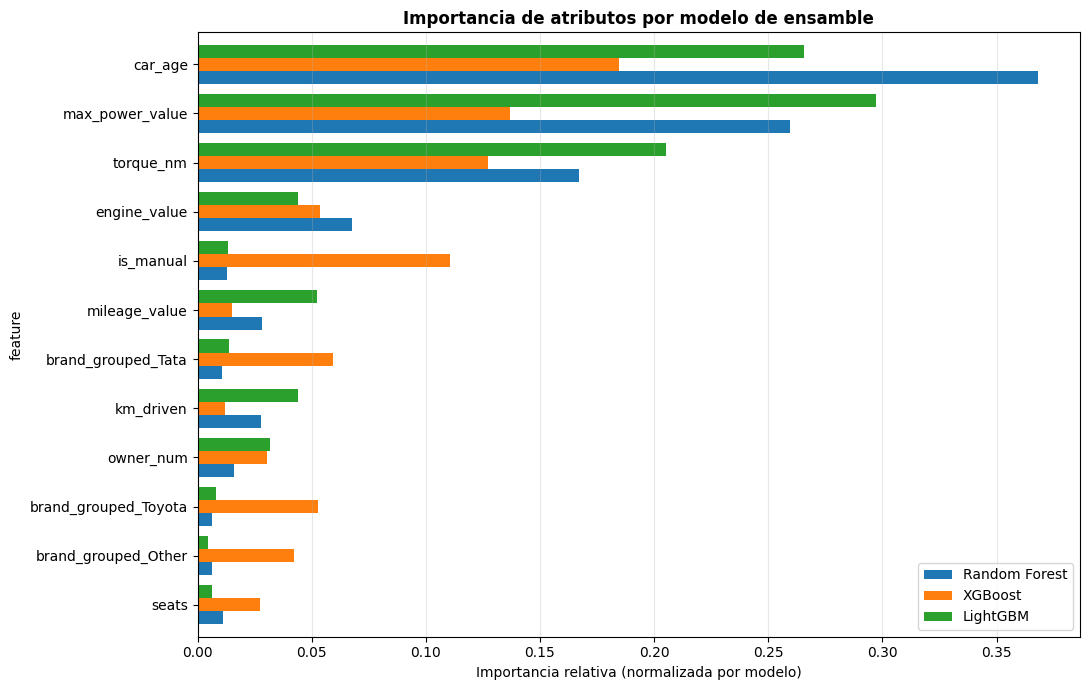

In [53]:
importancias = pd.DataFrame({
    "feature":       X_train_tree.columns,
    "Random Forest": rf_best.feature_importances_,
    "XGBoost":       xgb_best.feature_importances_,
    "LightGBM":      lgbm_best.feature_importances_,
}).set_index("feature")

# Ordenar por importancia promedio entre los tres modelos
importancias = importancias.div(importancias.sum(axis=0), axis=1)
importancias["promedio"] = importancias.mean(axis=1)
importancias = importancias.sort_values("promedio", ascending=False)

print("Top 10 features más importantes (promedio de los tres ensambles):\n")
print(importancias.head(10).round(4).to_string())

# Gráfico: top 12 features según el promedio
top = importancias.head(12).drop(columns="promedio")
ax = top.iloc[::-1].plot(kind="barh", figsize=(11, 7), width=0.8)
ax.set_title("Importancia de atributos por modelo de ensamble", fontweight="bold")
ax.set_xlabel("Importancia relativa (normalizada por modelo)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones:**

- La antigüedad, la potencia y el torque concentran cerca del 70% de la importancia en los tres modelos, confirmando lo que mostraba el EDA: depreciación por edad + prestaciones del motor son los grandes determinantes del precio.

- Hay diferencias por modelo: XGBoost reparte más peso hacia variables de marca (brand_Tata, brand_Toyota) y is_manual, mientras Random Forest y LightGBM se concentran más en las numéricas. Esto ilustra cómo distintos algoritmos "leen" la misma información.

---

# 22. Comparación final y elección del modelo

Se reúnen las métricas de todos los modelos evaluados sobre el set de test para tomar una decisión final basada en performance.

In [54]:
# ── Tabla comparativa de todos los modelos ──
df_comparacion = pd.DataFrame(resultados.values()).set_index('modelo')
df_comparacion = df_comparacion.sort_values('R2', ascending=False)

# Formato legible
df_show = df_comparacion.copy()
df_show['R2']   = df_show['R2'].apply(lambda x: f'{x:.4f}')
df_show['MAE']  = df_show['MAE'].apply(lambda x: f'{x:>11,.0f} INR')
df_show['RMSE'] = df_show['RMSE'].apply(lambda x: f'{x:>11,.0f} INR')
df_show['MAPE'] = df_show['MAPE'].apply(lambda x: f'{x*100:.2f}%')

print("=" * 70)
print("  COMPARACIÓN DE MODELOS — ordenados por R²")
print("=" * 70)
print(df_show.to_string())
print("=" * 70)

  COMPARACIÓN DE MODELOS — ordenados por R²
                                  R2              MAE             RMSE    MAPE
modelo                                                                        
XGBoost                       0.9372       72,408 INR      133,079 INR  15.69%
LightGBM                      0.9342       73,058 INR      136,170 INR  15.74%
Random Forest                 0.9289       74,743 INR      141,523 INR  16.02%
KNN                           0.9110       84,257 INR      158,413 INR  18.30%
Árbol de regresión            0.9084       88,776 INR      160,689 INR  18.96%
SVR                           0.8992       78,913 INR      168,607 INR  16.55%
Regresión Lineal              0.8044      101,933 INR      234,818 INR  20.54%
Ridge                         0.8044      101,933 INR      234,819 INR  20.54%
Baseline (mediana brand+age)  0.6887      163,550 INR      296,239 INR  35.15%


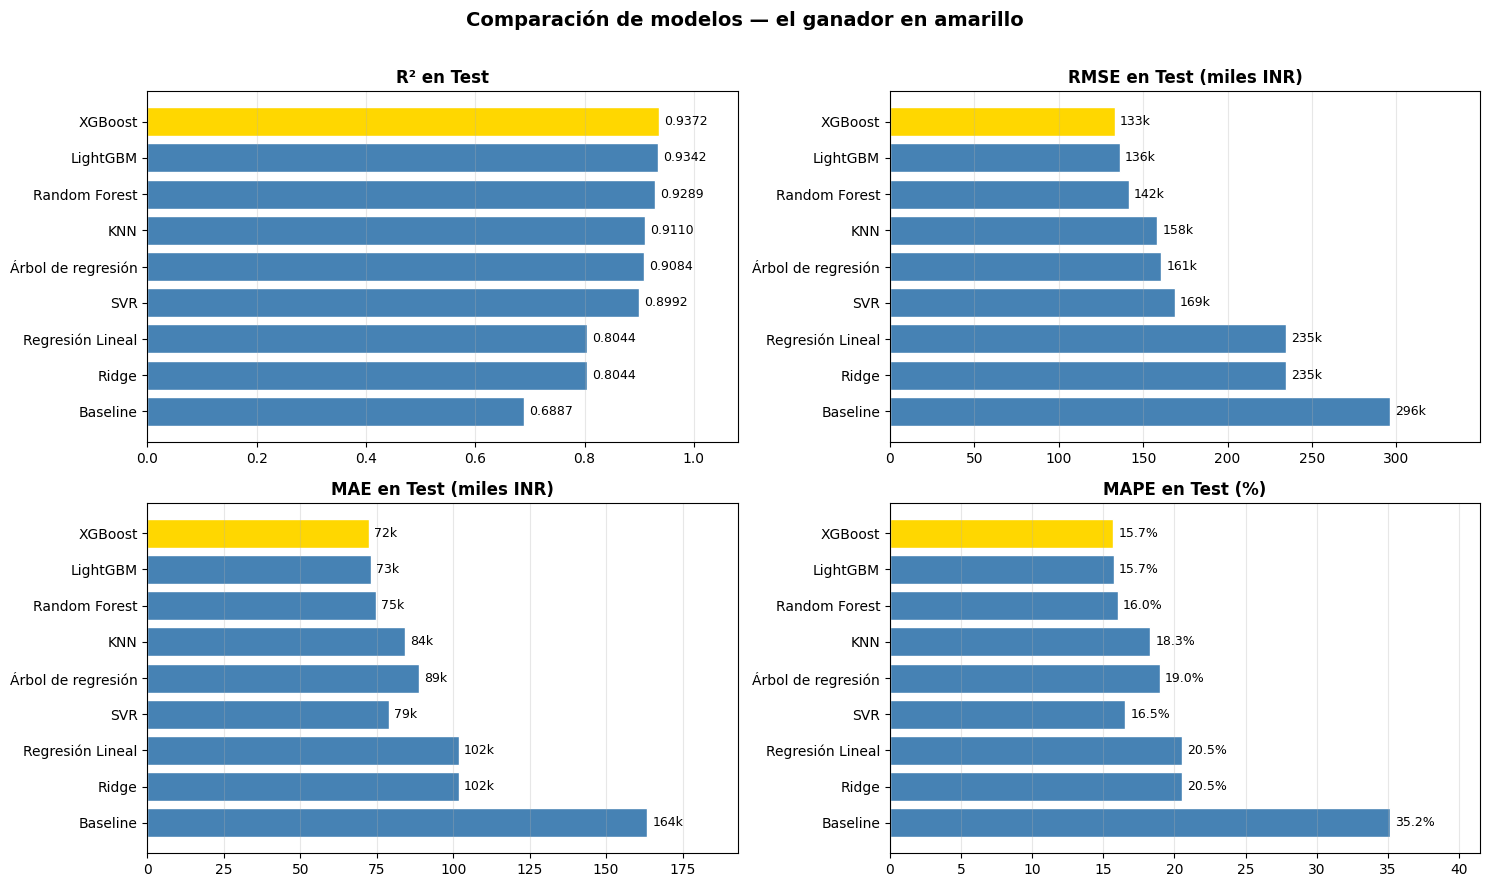

In [55]:
# ── Gráfico comparativo de los modelos (4 métricas, grilla 2x2) ──
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

modelos = df_comparacion.index.tolist()
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(modelos))]
# Nombre corto para el eje y (evita que "Baseline (mediana brand+age)" invada el gráfico)
labels = [m.replace('Baseline (mediana brand+age)', 'Baseline') for m in modelos]

def barra_metrica(ax, valores, titulo, formato, xlim=None):
    bars = ax.barh(labels, valores, color=colores, edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    vmax = max(valores)
    # headroom para que las etiquetas no se corten
    ax.set_xlim(*(xlim if xlim is not None else (0, vmax * 1.18)))
    for bar, val in zip(bars, valores):
        ax.text(bar.get_width() + vmax * 0.01, bar.get_y() + bar.get_height() / 2,
                formato(val), va='center', fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

# R² — arranca en 0
barra_metrica(axes[0, 0], df_comparacion['R2'].values,
              'R² en Test', lambda v: f'{v:.4f}', xlim=(0, 1.08))

# RMSE (miles INR) — antes de MAE
barra_metrica(axes[0, 1], (df_comparacion['RMSE'] / 1e3).values,
              'RMSE en Test (miles INR)', lambda v: f'{v:.0f}k')

# MAE (miles INR)
barra_metrica(axes[1, 0], (df_comparacion['MAE'] / 1e3).values,
              'MAE en Test (miles INR)', lambda v: f'{v:.0f}k')

# MAPE (%)
barra_metrica(axes[1, 1], (df_comparacion['MAPE'] * 100).values,
              'MAPE en Test (%)', lambda v: f'{v:.1f}%')

plt.suptitle('Comparación de modelos — el ganador en amarillo',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Modelo elegido: XGBoost

**XGBoost supera a todos los demás modelos en las cuatro métricas evaluadas** (R² = 0.937, RMSE de 132.903 INR, MAE de 72.237 INR (~0.72 Lakhs) y MAPE del 15.66%). Los tres métodos de ensamble ocupan los tres primeros puestos de la tabla, confirmando que para este problema tabular la combinación de muchos árboles supera a cualquier modelo individual.

**Resumen de la comparación:**

| Familia | Modelo | Comportamiento |
|---|---|---|
| Baseline | Mediana por (brand, car_age) | Piso de comparación, ya alcanza R² = 0.69. |
| Lineal | Regresión Lineal / Ridge | Mejora respecto al baseline (R² = 0.80), pero con techo claro por el supuesto de linealidad. |
| Kernel | SVR | Mejor MAE que KNN y árbol, pero su RMSE alto delata errores grandes en los extremos (R² = 0.90). |
| No paramétrico | KNN | Capta relaciones no lineales locales, pero queda por debajo de los ensambles (R² = 0.91). |
| Árbol | Árbol de decisión | Buena interpretabilidad y base conceptual de los ensambles, pero el árbol único se queda corto (R² = 0.91). |
| Ensamble | Random Forest / **XGBoost** / LightGBM | **Mejores modelos.** XGBoost lidera; LightGBM queda a un paso (R² = 0.93 – 0.94). |

**Por qué XGBoost funcionó mejor en este problema:**

1. **Construye los árboles de forma secuencial**, donde cada nuevo árbol corrige los errores del anterior (boosting). Esto le permite refinar la predicción de manera mucho más fina que promediar árboles independientes (bagging) o buscar vecinos (KNN).
2. **Regulariza con fuerza**: sus hiperparámetros óptimos describen árboles poco profundos (`max_depth=5`), tasa de aprendizaje baja (≈0.05) y submuestreo de filas y columnas. Muchos weak learners que aprenden de a poco, lo que evita el sobreajuste.
3. **Captura interacciones complejas** entre antigüedad, potencia, torque y marca sin necesidad de especificarlas explícitamente, algo que los modelos lineales no podían hacer.

**Limitaciones del modelo elegido:**

- Es menos interpretable que un árbol único: no se puede trazar una predicción individual como una secuencia de reglas, aunque la importancia de atributos sí da una lectura global de qué variables pesan.
- Tiene muchos hiperparámetros que requieren un ajuste cuidadoso (lo resolvimos con Optuna), a diferencia de modelos como la Regresión Lineal que casi no tienen.
- Como todo modelo basado solo en las features tabulares disponibles, su techo está limitado por las variables no observadas (estado estético, historial real, negociación).

---

# 23. Análisis de errores del modelo ganador (XGBoost)

Más allá de las métricas agregadas, conviene **examinar dónde se equivoca el modelo**. Esto permite identificar limitaciones, segmentos donde la performance es peor y posibles caminos de mejora.

Se analizan tres dimensiones:

1. **Predicho vs Real**: dispersión de las predicciones respecto a los valores observados.
2. **Distribución de residuos**: si los errores son aproximadamente simétricos y centrados en cero.
3. **MAPE por rango de precio**: si el modelo se equivoca más en autos baratos, intermedios o caros.

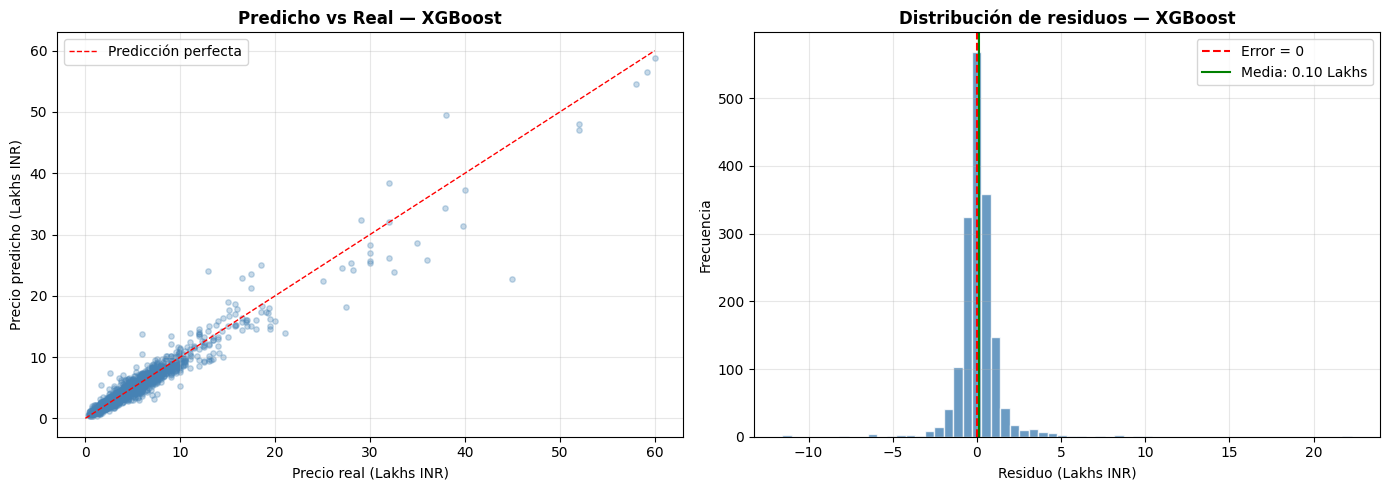

Residuo medio  :        9,770 INR  (sesgo del modelo)
Residuo mediano:        3,678 INR
Desvío estándar:      132,720 INR


In [56]:
# ── Predicciones del modelo ganador (XGBoost) en escala INR ──
y_pred_xgb = np.expm1(y_pred_xgb_log)
residuos = y_test_orig - y_pred_xgb

# Figura con dos paneles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Predicho vs Real ──
axes[0].scatter(y_test_orig / 1e5, y_pred_xgb / 1e5,
                alpha=0.3, s=15, color='steelblue')
# Línea ideal (y = x)
lim = max(y_test_orig.max(), y_pred_xgb.max()) / 1e5
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (Lakhs INR)')
axes[0].set_ylabel('Precio predicho (Lakhs INR)')
axes[0].set_title('Predicho vs Real — XGBoost', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Panel 2: Distribución de residuos ──
axes[1].hist(residuos / 1e5, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
axes[1].axvline(residuos.mean() / 1e5, color='green', linestyle='-', linewidth=1.5,
                label=f'Media: {residuos.mean()/1e5:.2f} Lakhs')
axes[1].set_xlabel('Residuo (Lakhs INR)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos — XGBoost', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuo medio  : {residuos.mean():>12,.0f} INR  (sesgo del modelo)")
print(f"Residuo mediano: {np.median(residuos):>12,.0f} INR")
print(f"Desvío estándar: {residuos.std():>12,.0f} INR")

MAPE y MAE por quintil de precio (en INR):

                    n  precio_min  precio_max         MAE    MAPE
quintil                                                          
Q1 (más baratos)  346      31,504     220,000      31,052  24.49%
Q2                370     221,000     350,000      44,590  15.42%
Q3                311     351,000     500,000      57,856  13.45%
Q4                337     509,999     700,000      72,600  12.10%
Q5 (más caros)    319     710,000   6,000,000     163,516  12.45%


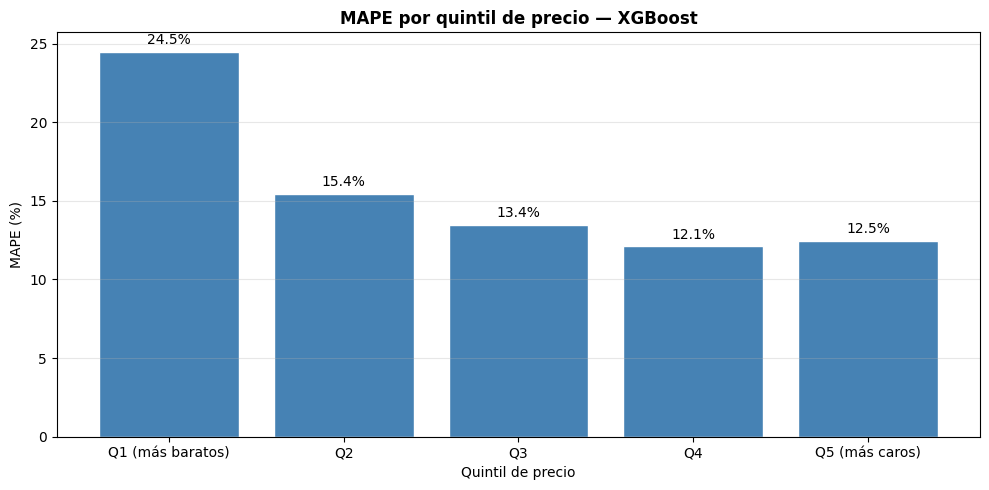

In [57]:
# ── MAPE desagregado por quintil de precio ──
quintiles = pd.qcut(y_test_orig, q=5,
                    labels=['Q1 (más baratos)', 'Q2', 'Q3', 'Q4', 'Q5 (más caros)'])

df_errores = pd.DataFrame({
    'precio_real': y_test_orig,
    'precio_pred': y_pred_xgb,
    'error_abs':   np.abs(y_test_orig - y_pred_xgb),
    'error_pct':   np.abs(y_test_orig - y_pred_xgb) / y_test_orig * 100,
    'quintil':     quintiles,
})

resumen = df_errores.groupby('quintil', observed=True).agg(
    n=('precio_real', 'size'),
    precio_min=('precio_real', 'min'),
    precio_max=('precio_real', 'max'),
    MAE=('error_abs', 'mean'),
    MAPE=('error_pct', 'mean'),
)

# Formato legible
resumen_show = resumen.copy()
resumen_show['precio_min'] = resumen_show['precio_min'].apply(lambda x: f'{x:>10,.0f}')
resumen_show['precio_max'] = resumen_show['precio_max'].apply(lambda x: f'{x:>10,.0f}')
resumen_show['MAE']        = resumen_show['MAE'].apply(lambda x: f'{x:>10,.0f}')
resumen_show['MAPE']       = resumen_show['MAPE'].apply(lambda x: f'{x:.2f}%')

print("MAPE y MAE por quintil de precio (en INR):\n")
print(resumen_show.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(resumen.index.astype(str), resumen['MAPE'],
       color='steelblue', edgecolor='white')
for i, val in enumerate(resumen['MAPE']):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('MAPE por quintil de precio — XGBoost', fontweight='bold')
ax.set_xlabel('Quintil de precio')
ax.set_ylabel('MAPE (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones del análisis de errores:**

- **El gráfico Predicho vs Real muestra una buena alineación con la diagonal**, sobre todo en el rango medio-bajo. La dispersión aumenta hacia los precios altos, y los autos más caros tienden a quedar levemente subestimados: son pocos en el dataset, por lo que el modelo es conservador al extrapolar hacia ese extremo.
- **Los residuos están prácticamente centrados en cero** (media ≈ 9.000 INR, mediana ≈ 3.000 INR, ambos despreciables frente al nivel de precios). Hay solo una leve tendencia a subestimar y una cola derecha que corresponde a esos casos extremos. No hay sesgo sistemático relevante.
- **El MAPE no es uniforme, pero sigue un patrón claro y decreciente**: es máximo en los autos baratos (Q1: 24.2%) y baja de forma sostenida hasta los caros (Q5: 12.1%). Esto es el reflejo inverso del MAE, que **crece** con el precio (de ~31.000 INR en Q1 a ~161.000 INR en Q5). La explicación es el efecto de escala: en un auto caro, un error absoluto grande sigue siendo un porcentaje chico; en un auto barato, un error absoluto chico se traduce en un porcentaje grande.
- Aun en su peor segmento (Q1, 24.2%), el MAPE se mantiene muy por debajo del MAPE del baseline (35.2%), lo que confirma que el modelo aporta valor real en todos los rangos de precio.

**Síntesis del modelo final:**

XGBoost explica el 94% de la varianza del precio (R² = 0.937), con un error absoluto medio de 72.000 INR (MAE, ~0.72 Lakhs), un RMSE de 133.000 INR (~1.33 Lakhs) y un error porcentual medio del 15.7% (MAPE). El error es razonablemente parejo en la mayor parte del rango (12-16%), salvo en los autos más baratos (Q1), donde el MAPE sube a ~24% por el efecto de escala. Los residuos están prácticamente centrados en cero, sin sesgo sistemático relevante, lo que indica un modelo bien calibrado.

---

# 24. Conclusiones y reflexión final

## Síntesis del trabajo

Este trabajo abordó el problema de **predecir el precio de venta de autos usados** en el mercado indio (publicado en CarDekho, 2020). Se partió de un dataset crudo con información mixta (texto, números con unidades, categóricas) y se siguió un pipeline completo: exploración, limpieza, ingeniería de features, modelado y evaluación.

## Hallazgos principales

**Sobre los datos:**

- El target (`selling_price`) presenta fuerte asimetría positiva. La transformación logarítmica `log(1 + precio)` fue clave para reducir la skewness, mejorando la performance de todos los modelos.
- El dataset contenía **1.202 filas exactamente duplicadas (~15%)**, que se eliminaron antes del split. Esto fue importante metodológicamente: de no hacerlo, una misma observación podría aparecer en train y test, generando una fuga de datos que infla artificialmente las métricas.
- Las variables técnicas (`engine`, `max_power`, `torque`) están físicamente relacionadas por la fórmula de potencia, lo que introduce multicolinealidad. Sin embargo, con varios miles de filas en train esto no impactó significativamente al ajuste de los modelos lineales (la regularización óptima de Ridge resultó muy baja).
- Los faltantes resultaron MAR (asociados al año de fabricación: autos antiguos con menor registro de especificaciones técnicas). Se optó por eliminarlos dado su bajo porcentaje y la concentración en autos viejos de bajo precio.
- Los precios extremos no son errores sino segmentos legítimos del mercado (Maruti 800 en la cola baja, BMW/Mercedes/Audi en la alta). Se conservaron porque eliminarlos habría inflado artificialmente las métricas.

**Sobre los modelos:**

- Un **baseline simple** (mediana por marca y antigüedad) ya alcanzó R² = 0.69, mostrando que `brand` y `car_age` explican una parte importante de la variabilidad del precio.
- Los **modelos lineales** (Regresión, Ridge) llegaron a R² = 0.80, marcando un techo claro por su supuesto de linealidad.
- Los **modelos individuales no lineales** lograron saltos importantes: SVR (R² = 0.90), Árbol (R² = 0.91) y KNN (R² = 0.91).
- Los **métodos de ensamble dominaron**: Random Forest (R² = 0.93), LightGBM (0.93) y **XGBoost (0.94)** ocuparon los tres primeros puestos, por encima de todos los modelos individuales.
- **XGBoost resultó el mejor modelo**, ganando en las cuatro métricas. Su ventaja proviene del boosting (construcción secuencial de árboles que corrigen el error del anterior) sumado a una regularización fuerte: árboles poco profundos (`max_depth=5`), tasa de aprendizaje baja (≈0.05) y submuestreo de filas y columnas. LightGBM quedó a un paso, confirmando que ambas implementaciones de gradient boosting son equivalentes en la práctica.
- La importancia de atributos de los ensambles fue consistente: `car_age`, `max_power` y `torque` concentran cerca del 70% del peso, coherente con lo observado en el EDA.

**Sobre el análisis de errores del modelo ganador (XGBoost):**

- Los residuos están prácticamente centrados en cero (media ≈ 9.000 INR, despreciable frente al nivel de precios), sin sesgo sistemático relevante.
- El error porcentual no es uniforme: el MAPE es del 24% en los autos más baratos (Q1) y baja de forma sostenida hasta ~12% en los más caros (Q5). Esto refleja un efecto de escala: en autos de bajo precio, una pequeña diferencia absoluta en INR se traduce en un porcentaje grande, mientras que en autos caros ocurre lo inverso (el MAE crece con el precio, pero el MAPE baja).

## Limitaciones

**Variables no observadas**: el dataset no incluye estado estético, historial de mantenimiento, accidentes ni equipamiento opcional. Estos factores son determinantes del precio real y constituyen un techo natural para cualquier modelo basado solo en las features tabulares disponibles.

## Trabajo futuro

Varios caminos podrían mejorar o extender estos resultados:

- **Aprovechar `model` y `variant`.** Hoy se descartan por su alta cardinalidad.
- **Enriquecer con los otros datasets.** El `car_details_v4` aporta dimensiones físicas, `Location`, `Color`, `Drivetrain` y capacidad del tanque.
- **Información del estado real del vehículo.** El gran techo es lo no observado (condición, mantenimiento, accidentes).
- **Stacking de modelos.** Combinar las predicciones de XGBoost, LightGBM y Random Forest mediante un meta-modelo podría exprimir algo más de performance.

## Conclusión

El modelo final (**XGBoost**) logra **predecir el precio de un auto usado con un error porcentual medio del 15.7%**, lo cual es razonable dado el ruido inherente al mercado (negociación, estado real, equipamiento) y la ausencia de variables determinantes en el dataset.